<a href="https://colab.research.google.com/github/EmanuelePinci/AML-project-IRIDE/blob/Simone/Radom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importazione librerie e moduli e configurazione del device

In [1]:
import torch
print(torch.__version__)

2.12.0+cpu


In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch.optim as optim
import torch.nn as nn
import joblib  # Per salvare gli scaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import optuna
import copy
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import seaborn as sns
from scipy.stats import spearmanr
import collections
import io
import urllib.request



In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch', torch.__version__, '| device →', device)

Torch 2.12.0+cpu | device → cpu


# 1. Dizionario per i nomi degli organi

Definiamo un dizionario per mappare i nomi degli organi e le relative metriche (dose media e massima) ai corrispondenti indici posizionali nel tensore di output.
Questa scelta architetturale centralizza la configurazione degli indici statici, garantendo diversi vantaggi:
 - Modularità: separa la definizione degli indici dalla logica di estrazione (Task 2 e 3).
 - Sicurezza: evita l'hardcoding ("magic numbers" sparsi nel codice), prevenendo errori.
 - Leggibilità: rende immediata la comprensione di quali feature fisiche si stanno manipolando durante le fasi di calcolo delle metriche e debugging.

In [4]:
# Mappatura per l'estrazione sicura delle colonne fisiche
MAPPA_COLONNE = {
    'tempo': 0,
    'crist_media': 1,  'crist_max': 3,
    'retina_media': 4, 'retina_max': 6,
    'cornea_media': 7, 'cornea_max': 9,
    'nervo_media': 10, 'nervo_max': 12,
    'sclera_media': 13, 'sclera_max': 15,
    'tumore_media': 16, 'tumore_max': 18
}

# 2. Caricamento dati e splitting deterministico

**2.1 Logica di Splitting**

Per garantire una rigorosa riproducibilità degli esperimenti, la divisione del dataset originario in *Training* (80%), *Validation* (10%) e *Test* (10%) è stata implementata tramite un partizionamento deterministico intervallato. Utilizzando l'operatore modulo e maschere booleane, i campioni vengono raggruppati in blocchi di 10 elementi: all'interno di ciascun blocco, i primi 8 costituiscono il set di addestramento, il nono quello di validazione e il decimo quello di test. Questo approccio previene il *data leakage* e garantisce che, a ogni esecuzione del codice, il modello venga valutato esattamente sullo stesso set di simulazioni fisiche.

**2.2 Data Augmentation con Vincoli Fisici**

La scarsità dei dati originali (solo 58 simulazioni destinate al training) rendeva il modello vulnerabile all'overfitting. Per ovviare al problema, è stata implementata una tecnica di *Data Augmentation* basata su un'assunzione fisica solida: applicando piccole perturbazioni geometriche (*kicks*) al posizionamento della placca radiante in 106Ru, la topologia del campo di dose (il rateo di dose sui tessuti oculari) non subisce stravolgimenti drastici. 

Operativamente:
* Sono state generate **29 copie rumorose** per ogni campione di training originale.
* L'angolo $\theta$ è stato perturbato con un rumore gaussiano avente deviazione standard di **1°**.
* Le restanti feature spaziali sono state modificate con un rumore moltiplicativo dell'**1%**.
* I valori di dose (target) sono stati mantenuti identici agli originali.

Questa strategia ha portato il *Training Set* a un totale di **1740 campioni**, consentendo l'adozione di un `batch_size` di **128**. Un lotto di dimensioni maggiori garantisce che gli aggiornamenti dei pesi durante la *backpropagation* si basino su gradienti statisticamente più stabili, evitando le marcate oscillazioni della *loss function* tipiche dei mini-batch troppo ridotti.

In [ ]:
# ==============================================================================
# 2.A CARICAMENTO DEL DATASET
# ==============================================================================

url_X = "https://raw.githubusercontent.com/EmanuelePinci/AML-project-IRIDE/main/input_tensor.npy"
url_y = "https://raw.githubusercontent.com/EmanuelePinci/AML-project-IRIDE/main/output_tensor.npy"

req_X = urllib.request.urlopen(url_X)
X = np.load(io.BytesIO(req_X.read()), allow_pickle=True)

req_y = urllib.request.urlopen(url_y)
y = np.load(io.BytesIO(req_y.read()), allow_pickle=True)

n_simulazioni = X.shape[0]

print(f"Dataset caricato con successo! Simulazioni totali: {n_simulazioni}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")

# ==============================================================================
# 2.B SPLITTING DETERMINISTICO (80% Train, 10% Val, 10% Test)
# ==============================================================================
# Creiamo un vettore sequenziale di indici
indici = np.arange(n_simulazioni) 

# Vogliamo dividere il dataset in train, validation e test. Per farlo si usano delle maschere 
# booleane per stabilire le condizioni di campionamento e riempimento dell'input (x) e output (y).
# L'operatore modulo (%) crea blocchi ripetitivi di 10 elementi da cui si estrapolano i dati.

# Maschere booleane basate sull'operatore modulo 10
mask_train = (indici % 10) < 8   # Indici uscenti in: 0,1,2,3,4,5,6,7
mask_val   = (indici % 10) == 8  # Indici uscenti in: 8
mask_test  = (indici % 10) == 9  # Indici uscenti in: 9

# Estrazione deterministica dei dati di train, validation e test
X_train, y_train = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val], y[mask_val]
X_test, y_test = X[mask_test], y[mask_test]

print(f"Dati training: {len(X_train)} \n"
      f"Dati validation: {len(X_val)} \n"
      f"Dati test: {len(X_test)} \n")

# ==============================================================================
# 2.C DATA AUGMENTATION (APPLICATA SOLO AL TRAINING SET)
# ==============================================================================

num_copie_aggiuntive = 29

X_aug_list = [X_train]
y_aug_list = [y_train]

# Deviazione standard di 1 grado (convertito in radianti)
std_dev_rad = np.radians(1.0)

for _ in range(num_copie_aggiuntive):
    X_noisy = X_train.copy()

    # 1. Estrazione dell'angolo theta dai valori di sin(theta) e cos(theta) originali
    theta = np.arctan2(X_noisy[:, 0], X_noisy[:, 1])

    # 2. Produzione del rumore gaussiano e definizione del nuovo angolo (somma tra rumore gaussiano e angolo originale)
    rumore = np.random.normal(loc=0.0, scale=std_dev_rad, size=theta.shape)
    theta_noisy = theta + rumore

    # 3. Ricalcolo delle nuove variabili sin(theta) e cos(theta)
    X_noisy[:, 0] = np.sin(theta_noisy)
    X_noisy[:, 1] = np.cos(theta_noisy)

    # 4. Iniezione di un rumore dell'1% anche sugli altri input per evitare che la rete impari a memoria
    rumore_moltiplicativo = np.random.normal(loc=1.0, scale=0.01, size=X_noisy[:, 2:].shape)
    X_noisy[:, 2:] = X_noisy[:, 2:] * rumore_moltiplicativo

    X_aug_list.append(X_noisy)
    y_aug_list.append(y_train) # Il target rimane IDENTICO

# Concatenazione del nuovo dataset arricchito
X_train = np.vstack(X_aug_list)
y_train = np.vstack(y_aug_list)

print(f"Campioni di Training DOPO l'Augmentation: {X_train.shape[0]}")
# ==============================================================================
# 2.D PREPROCESSING: TRASFORMAZIONE LOGARITMICA E SCALING
# ==============================================================================
# 1. Appiattiamo la varianza fisica (che spazia da pochi Gy a migliaia di Gy)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# 2. Inizializzazione e fitting degli scaler (solo sul Training set)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train).astype('float32')
y_train_scaled = scaler_y.fit_transform(y_train_log).astype('float32')

X_val_scaled = scaler_X.transform(X_val).astype('float32')
y_val_scaled = scaler_y.transform(y_val_log).astype('float32')

X_test_scaled = scaler_X.transform(X_test).astype('float32')
y_test_scaled = scaler_y.transform(y_test_log).astype('float32')

# Salvataggio degli scaler per l'inferenza futura
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

# ==============================================================================
# 2.E CREAZIONE DEI DATALOADERS PYTORCH
# ==============================================================================

X_train_t = torch.tensor(X_train_scaled)
y_train_t = torch.tensor(y_train_scaled)
X_val_t = torch.tensor(X_val_scaled)
y_val_t = torch.tensor(y_val_scaled)
X_test_t = torch.tensor(X_test_scaled)
y_test_t = torch.tensor(y_test_scaled)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

Dataset caricato con successo! Simulazioni totali: 72
Shape X: (72, 5) | Shape y: (72, 19)
Dati training: 58 
Dati validation: 7 
Dati test: 7 

Campioni di Training DOPO l'Augmentation: 1740


# 3. Definizione Modello e Loss Function



**3.1 Motivazione dell'Architettura**

Il modello implementato è un **Multi-Layer Perceptron (MLP) con architettura residua (Skip Connection)**. Inizialmente, la scelta esplorativa era ricaduta su un MLP puramente sequenziale (es. $5 \rightarrow 64 \rightarrow 32 \rightarrow 19$), ma tale struttura presentava evidenti criticità: il numero ridotto di neuroni nei layer nascosti creava un "collo di bottiglia" informativo, faticando a mappare in modo accurato l'alta dimensionalità dell'output (19 grandezze fisiche distinte). Inoltre, l'applicazione di un *dropout* elevato su una rete stretta rischiava di causare un sotto-adattamento (underfitting), inibendo eccessivamente la capacità espressiva del modello.

Per superare questi limiti strutturali, si è optato per un'architettura più ampia ($128$ neuroni per layer) dotata di una connessione residua, che divide il flusso dell'informazione vettoriale in due percorsi paralleli:
* **Percorso di trasformazione:** un blocco profondo deputato all'apprendimento delle relazioni non lineari complesse.
* **Percorso d'identità (Residuo):** la *skip connection* vera e propria, che permette all'input del blocco di scavalcare i layer intermedi preservando l'informazione originaria.

Al termine del blocco, i due tensori vengono sommati elemento per elemento. Questa topologia non solo facilita il flusso dei gradienti durante la *backpropagation*, ma permette alla rete di focalizzarsi esclusivamente sull'apprendimento delle piccole "correzioni" non lineari (*residuals*), garantendo una convergenza nettamente più rapida e stabile.

In [ ]:
# ==============================================================================
# 3. DEFINIZIONE DEL MODELLO IN PYTORCH
# ==============================================================================
# Implementiamo un modello MLP ResNet-like. Questa architettura preserva l'identità
# del tensore di input attraverso il blocco centrale, focalizzando l'aggiornamento 
# dei pesi esclusivamente sulle correzioni non lineari.

class ModelloSurrogato(nn.Module):
    
    def __init__(self, input_dim=5, output_dim=19, hidden_dim=128, dropout_rate=0.15):
        super(ModelloSurrogato, self).__init__()

        # 1. Strato di proiezione in ingresso: 5 input --> 128 feature latenti 
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU())
        
        # 2. Blocco residuo (stessa dimensionalità in input e output)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.gelu1 = nn.GELU()

        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.gelu2 = nn.GELU()

        # 3. Regolarizzazione Dropout 
        self.dropout = nn.Dropout(dropout_rate)

        # 4. Strato di proiezione in uscita: 128 --> 19 output (target fisici)
        self.output_layer = nn.Linear(hidden_dim, output_dim)
    
    # Il metodo forward mappa esplicitamente la topologia della rete, gestendo la biforcazione e il ricongiungimento dei tensori.
    
    def forward(self, x):
        # 1. Proiezione nello spazio latente
        x_hidden = self.input_layer(x)

        # 2. Salvataggio del tensore per la skip connection
        residual = x_hidden

        # 3. Elaborazione attraverso il blocco intermedio
        out = self.gelu1(self.linear1(x_hidden))
        out = self.linear2(out)

        # 4. Ricongiungimento (somma vettoriale element-wise) e attivazione
        out = self.gelu2(out+residual)

        # 5. Regolarizzazione finale e proiezione agli output
        out = self.dropout(out)
        return self.output_layer(out)

# Istanziazione del modello e caricamento sul device (CPU/GPU)    
modello = ModelloSurrogato().to(device)


**3.2 Definizione della Loss Function Personalizzata (Weighted MSE)**

Nel contesto della brachiterapia oculare, non tutti i distretti anatomici presentano la medesima criticità. Un errore di predizione della dose sul nervo ottico o sul tumore ha un impatto clinico (e quindi un rischio radiologico) nettamente superiore rispetto a un'imprecisione sulla sclera, un tessuto estremamente radioresistente che, trovandosi a diretto contatto con la placca, assorbe inevitabilmente dosi massive.

Per tradurre questa priorità clinica nell'addestramento della rete neurale, è stata implementata una funzione di costo personalizzata basata sull'Errore Quadratico Medio Pesato (*Weighted Mean Squared Error*). Questa classe permette di assegnare un vettore di pesi statici ai 19 output del modello: i tessuti a rischio maggiore ricevono un peso superiore, amplificando proporzionalmente la penalità nella *loss*. Questo approccio forza matematicamente l'algoritmo di ottimizzazione a concentrare gli aggiornamenti dei gradienti per minimizzare l'errore sugli organi vitali, garantendo predizioni più sicure e conservative.

In [ ]:
# ==============================================================================
# 3.2 CUSTOM LOSS FUNCTION (WEIGHTED MSE)
# ==============================================================================
# Implementiamo una funzione di costo MSE pesata. I pesi permettono di modulare
# l'importanza di ciascuna delle 19 feature fisiche durante la backpropagation,
# penalizzando maggiormente gli errori commessi sugli organi clinicamente critici.
class CustomWeightedMSELoss(nn.Module):
    def __init__(self, pesi_colonne, device):
        """
        Inizializza la Loss pre-caricando il vettore dei pesi clinici.
        Il tensore viene istanziato direttamente sul medesimo device (CPU/GPU) 
        per evitare colli di bottiglia nel trasferimento dati durante il training.
        """
        super(CustomWeightedMSELoss, self).__init__()
        self.pesi = torch.tensor(pesi_colonne, dtype=torch.float32).to(device)

    def forward(self, predizioni, target):
        """
        Calcola l'errore quadratico medio pesato per il batch corrente.
        """
        # 1. Calcolo dell'errore quadratico puro (elemento per elemento)
        errore_quadratico = (predizioni - target) ** 2
        # 2. Ponderazione vettoriale: moltiplica ogni colonna (organo/feature) per il suo peso
        errore_pesato = errore_quadratico * self.pesi
        # 3. Riduzione in un singolo valore scalare tramite media
        return torch.mean(errore_pesato)

**3.3 Implementazione della Logica di Early Stopping**

Al fine di prevenire il fenomeno dell'overfitting e ottimizzare i tempi computazionali, è stata implementata una logica di *Early Stopping*. Questo meccanismo funge da regolarizzatore dinamico: monitora l'andamento della funzione di costo sul *Validation Set* durante il training e interrompe anticipatamente l'addestramento se non si registrano miglioramenti significativi per un numero consecutivo di epoche. 

Il grado di tolleranza è governato da due iperparametri:
* `min_delta`: definisce il miglioramento minimo richiesto per considerare un'epoca effettivamente "migliore" della precedente.
* `patience`: definisce il numero massimo di epoche senza miglioramenti che l'algoritmo è disposto ad attendere prima di arrestarsi.

Grazie a questa classe, è possibile impostare un numero massimo teorico di epoche molto elevato, delegando all'algoritmo il compito di fermarsi in autonomia al raggiungimento della convergenza. Come verrà illustrato in dettaglio nella successiva fase di training (Sezione 5.1), al termine del processo vengono ripristinati e salvati i pesi della rete corrispondenti alla *loss* di validazione minima, garantendo che il modello conservato sia sempre il più generalizzabile.

In [ ]:
# ==============================================================================
# 3.3 CLASSE EARLY STOPPING
# ==============================================================================
# Monitora la Validation Loss e interrompe il training se il modello smette 
# di migliorare, prevenendo l'overfitting sui dati di addestramento.

class EarlyStopping:
    
    def __init__(self, patience=15, min_delta=1e-4):
        """
        Inizializza l'Early Stopping.
        
        Parametri:
        - patience (int): Epoche da attendere senza miglioramenti prima di fermarsi.
        - min_delta (float): Variazione minima della loss per qualificare un miglioramento.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss= float('inf')
        self.early_stop = False 
    
    def __call__(self, val_loss):
        """
        Viene chiamata alla fine di ogni epoca per valutare la loss corrente.
        """
        # Se la loss attuale migliora il record precedente di almeno 'min_delta'
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 # Azzera il contatore della pazienza
        # Se la loss non migliora in modo significativo
        else:
            self.counter += 1
            # Se la pazienza è esaurita, attiva il flag di stop
            if self.counter >= self.patience:
                self.early_stop = True

# 4. Funzione di ottimizzazione dei parametri 

**4.1 Argomentazione delle Scelte Architetturali**

Per determinare il set ottimale di pesi da assegnare a ciascun organo e individuare il *learning rate* ideale, è stata implementata una pipeline di ricerca automatizzata tramite la libreria Optuna.

Un passaggio matematico cruciale in questa fase riguarda la scelta della metrica di validazione per guidare lo studio. Se Optuna valutasse le performance di un *trial* utilizzando la medesima *Loss Pesata* impiegata per l'addestramento, l'algoritmo andrebbe incontro a un banale collasso (fenomeno del *weight collapse*): tenderebbe a spingere tutti i pesi verso lo zero al solo scopo di annullare algebricamente il valore della funzione di costo, eludendo il reale apprendimento. 

Per prevenire questa anomalia, durante la validazione viene calcolata una metrica MSE standard e non pesata. Questa separazione forza l'ottimizzatore a premiare unicamente le combinazioni di pesi che inducono la rete a minimizzare l'errore fisico assoluto (reale) sulle predizioni.

Infine, per garantire l'efficienza computazionale, è stato integrato un meccanismo di *pruning* (`MedianPruner`): questa tecnica monitora le curve di apprendimento intermedie e interrompe precocemente i *trial* che si dimostrano meno promettenti rispetto alla mediana degli esperimenti storici, evitando sprechi di risorse computazionali.

In [ ]:
# ==============================================================================
# 4. OTTIMIZZAZIONE DEGLI IPERPARAMETRI (OPTUNA)
# ==============================================================================
# Ottimizziamo: 
# - I pesi specifici per ogni organo (dose media e massima separati).
# - Il fattore di peso per le deviazioni standard.
# - Il learning rate.

def objective(trial):

    # 1. Spazio di ricerca per i pesi clinici
    # Tempo di trattamento
    w_tempo = trial.suggest_float('w_tempo', 5.0, 30.0)

    # Organi (media e max ottimizzati separatamente per riflettere le priorità cliniche)
    w_cristallino_m = trial.suggest_float('w_cristallino_m', 0.5,  10.0)
    w_cristallino_x = trial.suggest_float('w_cristallino_x', 0.5,  10.0)
    w_retina_m      = trial.suggest_float('w_retina_m',      0.5,  10.0)
    w_retina_x      = trial.suggest_float('w_retina_x',      0.5,  10.0)
    w_cornea_m      = trial.suggest_float('w_cornea_m',      0.5,  10.0)
    w_cornea_x      = trial.suggest_float('w_cornea_x',      0.5,  10.0)
    w_nervo_m       = trial.suggest_float('w_nervo_m',       2.0,  20.0)
    w_nervo_x       = trial.suggest_float('w_nervo_x',       2.0,  20.0)
    w_sclera_m      = trial.suggest_float('w_sclera_m',      0.5,  10.0)
    w_sclera_x      = trial.suggest_float('w_sclera_x',      0.5,  10.0)
    w_tumore_m      = trial.suggest_float('w_tumore_m',      2.0,  20.0)
    w_tumore_x      = trial.suggest_float('w_tumore_x',      2.0,  20.0)

    # La deviazione standard indica variabilità, ha un'importanza clinica minore
    w_std_factor = trial.suggest_float('w_std_factor', 0.1, 0.5)

    # Learning rate esplorato su scala logaritmica
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)

    # 2. Costruzione del vettore pesi ordinato per le 19 colonne di output
    pesi_trial = [
        w_tempo,
        w_cristallino_m, w_cristallino_m * w_std_factor, w_cristallino_x,
        w_retina_m,      w_retina_m      * w_std_factor, w_retina_x,
        w_cornea_m,      w_cornea_m      * w_std_factor, w_cornea_x,
        w_nervo_m,       w_nervo_m       * w_std_factor, w_nervo_x,
        w_sclera_m,      w_sclera_m      * w_std_factor, w_sclera_x,
        w_tumore_m,      w_tumore_m      * w_std_factor, w_tumore_x,
    ]

    model_trial     = ModelloSurrogato().to(device)

    # 3. Definizione delle metriche
    # In fase di validazione viene usata una metrica di errore assoluta e non pesata poiché in questo modo  Optuna può trovare la combinazione dei pesi necessaria a minimizzare l'errore reale senza poter minimizzare i coefficienti riducendo a zero la loss.
    
    criterion_eval = nn.MSELoss() # Metrica "pura" per Optuna
    criterion_trial = CustomWeightedMSELoss(pesi_trial, device) # Usata per aggiornare i gradienti
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=learning_rate)
    scheduler_trial = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial, mode='min', factor=0.5, patience=7
    )

    early_stopper_trial    = EarlyStopping(patience = 20)
    max_epochs_trial       = 200
    best_val_metric_trial  = float('inf')

    # 4. Loop di addestramento del singolo trial
    for epoch in range(max_epochs_trial):
        model_trial.train() # <-- Dichiarazione del modello in fase di addestramento 
        for bX, by in train_loader:
            bX, by = bX.to(device), by.to(device)
            optimizer_trial.zero_grad() # L'algoritmo in questa fase si aggiorna in base ai pesi correnti 
            # Loss pesata per orientare i gradienti verso gli organi critici
            loss = criterion_trial(model_trial(bX), by)
            loss.backward()
            optimizer_trial.step()
        # Fase di validazione
        model_trial.eval()
        val_metric_epoch = 0.0
        with torch.no_grad():
            for bX, by in val_loader:
                predizioni = model_trial(bX)
                # Calcolo dell'MSE fisico (senza i moltiplicatori dei pesi)
                val_metric_epoch += criterion_eval(predizioni, by).item()*bX.size(0)
    
        val_metric_epoch /= len(val_loader.dataset)

        if val_metric_epoch < best_val_metric_trial:
            best_val_metric_trial = val_metric_epoch

        # Aggiornamento dello scheduler sulla metrica reale 
        scheduler_trial.step(val_metric_epoch)


        # Report dello stato corrente a Optuna per l'analisi di Pruning
        trial.report(val_metric_epoch, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Controllo Early Stopping per questo specifico trial
        early_stopper_trial(val_metric_epoch)
        if early_stopper_trial.early_stop:
            print(f"Early Stopping attivato all'epoca {epoch}! Ripristino i pesi migliori.")
            break

    return best_val_metric_trial

# ==============================================================================
# ESECUZIONE DELLO STUDIO OPTUNA
# ==============================================================================
# Creiamo uno studio mirato alla minimizzazione della validation loss pura,
# abilitando l'eliminazione dei trial non promettenti tramite MedianPruner.
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner()
)

print("Inizio ottimizzazione iperparametri con Optuna...")
study.optimize(objective, n_trials=15)

print("\n" + "="*55)
print("  OTTIMIZZAZIONE COMPLETATA")
print("="*55)
print(f"Miglior Val Loss: {study.best_value:.6f}")
print("Parametri ottimali:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.6f}")
print("="*55)

[I 2026-07-25 09:55:07,848] A new study created in memory with name: no-name-805ec632-989a-4055-996f-839b6ecbde4b


Inizio ottimizzazione iperparametri con Optuna...


[I 2026-07-25 09:55:17,738] Trial 0 finished with value: 0.10115271806716919 and parameters: {'w_tempo': 20.661935809419077, 'w_cristallino_m': 6.493738602627245, 'w_cristallino_x': 2.2779165632171976, 'w_retina_m': 7.735235536134943, 'w_retina_x': 9.54877105512207, 'w_cornea_m': 0.5000536160708426, 'w_cornea_x': 4.648921713918574, 'w_nervo_m': 10.55419525494834, 'w_nervo_x': 3.898035688822871, 'w_sclera_m': 4.2441466645932024, 'w_sclera_x': 5.5387705733525685, 'w_tumore_m': 17.09101053645766, 'w_tumore_x': 11.009047626399788, 'w_std_factor': 0.4815578247295521, 'learning_rate': 1.3780322107746204e-05}. Best is trial 0 with value: 0.10115271806716919.
[I 2026-07-25 09:55:27,650] Trial 1 finished with value: 0.15761756896972656 and parameters: {'w_tempo': 29.797173557889955, 'w_cristallino_m': 6.360027456387679, 'w_cristallino_x': 7.481646352962839, 'w_retina_m': 7.136991804571492, 'w_retina_x': 9.148552712431915, 'w_cornea_m': 8.093092054071077, 'w_cornea_x': 0.5519036278929446, 'w_ner

Early Stopping attivato all'epoca 99! Ripristino i pesi migliori.


[I 2026-07-25 09:55:41,552] Trial 3 finished with value: 0.0683516263961792 and parameters: {'w_tempo': 19.7964784579554, 'w_cristallino_m': 4.887153218730044, 'w_cristallino_x': 7.102998028908188, 'w_retina_m': 7.109451887278397, 'w_retina_x': 5.569867907615357, 'w_cornea_m': 5.307286416909536, 'w_cornea_x': 8.71207715406244, 'w_nervo_m': 14.208615032399134, 'w_nervo_x': 5.489658355415098, 'w_sclera_m': 2.843824504728801, 'w_sclera_x': 1.222693313692319, 'w_tumore_m': 18.57739054359407, 'w_tumore_x': 14.847445467756089, 'w_std_factor': 0.42899244845200724, 'learning_rate': 2.1341674330728183e-05}. Best is trial 2 with value: 0.00620109960436821.
[I 2026-07-25 09:55:46,108] Trial 4 finished with value: 0.006588870193809271 and parameters: {'w_tempo': 15.669533907795396, 'w_cristallino_m': 9.101986075174974, 'w_cristallino_x': 5.731250444439214, 'w_retina_m': 2.3423673086944152, 'w_retina_x': 7.9077885437774125, 'w_cornea_m': 1.9186661346983862, 'w_cornea_x': 1.0224234911705556, 'w_nerv

...

Early Stopping attivato all'epoca 80! Ripristino i pesi migliori.


[I 2026-07-25 09:56:10,089] Trial 11 finished with value: 0.006351605523377657 and parameters: {'w_tempo': 5.064789931089917, 'w_cristallino_m': 1.063642795621286, 'w_cristallino_x': 0.7775346462959787, 'w_retina_m': 9.453771930596227, 'w_retina_x': 1.2554257026301363, 'w_cornea_m': 9.32931351075113, 'w_cornea_x': 9.79691972212187, 'w_nervo_m': 5.762019539626079, 'w_nervo_x': 19.750046876963577, 'w_sclera_m': 6.109003814275818, 'w_sclera_x': 9.74891887868593, 'w_tumore_m': 14.155641097544976, 'w_tumore_x': 19.794697118330813, 'w_std_factor': 0.28961196623363766, 'learning_rate': 0.0014593142875358597}. Best is trial 10 with value: 0.006031436379998922.


Early Stopping attivato all'epoca 72! Ripristino i pesi migliori.


[I 2026-07-25 09:56:11,962] Trial 12 finished with value: 0.006646814290434122 and parameters: {'w_tempo': 9.38405412521311, 'w_cristallino_m': 3.2849211858000182, 'w_cristallino_x': 0.8324578206379925, 'w_retina_m': 8.870808127668239, 'w_retina_x': 3.9908128425758918, 'w_cornea_m': 3.094653407467354, 'w_cornea_x': 8.027062230775494, 'w_nervo_m': 8.622914383742987, 'w_nervo_x': 15.584858664604646, 'w_sclera_m': 5.626711516007625, 'w_sclera_x': 9.647742342475494, 'w_tumore_m': 14.265804871901034, 'w_tumore_x': 19.228804819537938, 'w_std_factor': 0.3364768552810405, 'learning_rate': 0.0019144880047337112}. Best is trial 10 with value: 0.006031436379998922.
[I 2026-07-25 09:56:12,027] Trial 13 pruned. 
[I 2026-07-25 09:56:12,083] Trial 14 pruned. 


Early Stopping attivato all'epoca 43! Ripristino i pesi migliori.

  OTTIMIZZAZIONE COMPLETATA
Miglior Val Loss: 0.006031
Parametri ottimali:
  w_tempo: 6.134305
  w_cristallino_m: 0.927557
  w_cristallino_x: 0.548654
  w_retina_m: 9.532150
  w_retina_x: 0.598836
  w_cornea_m: 9.800740
  w_cornea_x: 9.865996
  w_nervo_m: 7.259272
  w_nervo_x: 18.542746
  w_sclera_m: 5.825044
  w_sclera_x: 9.430871
  w_tumore_m: 14.151553
  w_tumore_x: 18.794264
  w_std_factor: 0.293343
  learning_rate: 0.001522


# 5. Sviluppo dell'algoritmo e completamento della task 1 

**5.1 Addestramento Definitivo del Modello Surrogato**

In questa sezione viene eseguito l'addestramento finale della rete neurale. Mentre l'allenamento iterativo effettuato all'interno dei *trial* di Optuna aveva uno scopo puramente euristico (individuare il *learning rate* e i pesi clinici ottimali), questa fase consolida il modello addestrandolo in modo sistematico sull'intero *Training Set* con i parametri definitivi.

Per garantire la massima capacità di generalizzazione e scongiurare l'overfitting, sono state implementate tre diverse strategie concorrenti:
1. **Funzione di Costo Pesata:** Costruita utilizzando il dizionario dei pesi ottimali di Optuna, garantisce che l'algoritmo minimizzi prioritariamente gli errori sugli organi più critici (es. nervo ottico e tumore).
2. **Regolarizzazione L2 (Weight Decay):** Inserita direttamente all'interno dell'ottimizzatore Adam, penalizza i pesi sinaptici troppo grandi, costringendo la rete a distribuire l'apprendimento su tutti i neuroni in modo omogeneo.
3. **Monitoraggio Dinamico (Early Stopping & Model Checkpointing):** Durante le epoche, il sistema valuta costantemente la *Validation Loss*. I pesi della rete vengono salvati fisicamente (`modello_migliore.pth`) solo a fronte di un effettivo miglioramento. Al termine del ciclo, o all'attivazione dell'Early Stopping, il codice ripristina automaticamente l'ultimo stato ottimale, assicurando che il modello conservato in memoria sia matematicamente il più robusto possibile.

In [ ]:
# ==============================================================================
# 5.A INIZIALIZZAZIONE CON I MIGLIORI IPERPARAMETRI DI OPTUNA
# ==============================================================================
# Caricamento dei migliori risultati ottenuti dallo studio

# Caricamento dei migliori risultati ottenuti con OPTUNA
bp = study.best_params

# Ricostruzione del vettore dei pesi definitivi
pesi_personalizzati = [
    bp['w_tempo'],
    bp['w_cristallino_m'], bp['w_cristallino_m'] * bp['w_std_factor'], bp['w_cristallino_x'],
    bp['w_retina_m'],      bp['w_retina_m']      * bp['w_std_factor'], bp['w_retina_x'],
    bp['w_cornea_m'],      bp['w_cornea_m']       * bp['w_std_factor'], bp['w_cornea_x'],
    bp['w_nervo_m'],       bp['w_nervo_m']        * bp['w_std_factor'], bp['w_nervo_x'],
    bp['w_sclera_m'],      bp['w_sclera_m']       * bp['w_std_factor'], bp['w_sclera_x'],
    bp['w_tumore_m'],      bp['w_tumore_m']       * bp['w_std_factor'], bp['w_tumore_x'],
]

learning_rate = bp['learning_rate']

# Inizializzazione della Loss con i pesi clinici ottimizzati
criterion = CustomWeightedMSELoss(pesi_personalizzati, device)

# ==============================================================================
# 5.B SETUP DI OTTIMIZZATORE, SCHEDULER ED EARLY STOPPING
# ==============================================================================
# Aggiunta del weight_decay (Regolarizzazione L2) per prevenire l'overfitting 
# e mantenere i pesi della rete il più piccoli e stabili possibile.
optimizer = torch.optim.Adam(modello.parameters(), lr=learning_rate, weight_decay=1e-4)

# Lo scheduler dimezza (factor=0.8) il learning rate se la val_loss entra in plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=7)

# Istanza per l'interruzione anticipata
early_stopper = EarlyStopping(patience = 20) 

# ==============================================================================
# 5.C TRAINING LOOP DEFINITIVO
# ==============================================================================

num_epochs = 500
best_val_loss = float('inf')

train_losses = []
val_losses = []

print("\nInizio Addestramento...")
for epoch in range(num_epochs):

    # --- FASE DI ADDESTRAMENTO ---
    modello.train()
    train_loss = 0.0
    for bX, by in train_loader:
        bX, by = bX.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(modello(bX), by)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * bX.size(0)

    # --- FASE DI VALIDAZIONE ---
    modello.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bX, by in val_loader:
            val_loss += criterion(modello(bX), by).item() * bX.size(0)

    # Normalizzazione delle loss sul numero totale di campioni
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    # Controllo dinamico dello scheduler sul learning rate
    lr_precedente = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_nuovo = optimizer.param_groups[0]['lr']

    if lr_precedente != lr_nuovo:
        print(f"\n[!] Attenzione: Learning Rate ridotto da {lr_precedente:.6f} a {lr_nuovo:.6f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --- MODEL CHECKPOINTING ---
    # Salva il modello solo se c'è un miglioramento effettivo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(modello.state_dict(), 'modello_migliore.pth')

    if (epoch + 1) % 50 == 0: # Stampa log ogni 50 epoche
        print(f"Epoca [{epoch+1:4d}/{num_epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    # --- EARLY STOPPING ---
    early_stopper(val_loss)
    if early_stopper.early_stop:
        print(f"Early Stopping attivato all'epoca {epoch}! Ripristino i pesi migliori.")
        break

# ==============================================================================
# 5.D RIPRISTINO DEL MODELLO OTTIMALE
# ==============================================================================
# Al termine (naturale o forzato) del ciclo, si ricaricano i pesi associati
# alla minima validation loss registrata, scartando gli ultimi aggiornamenti rumorosi.
modello.load_state_dict(torch.load('modello_migliore.pth'))



Inizio Addestramento...

[!] Attenzione: Learning Rate ridotto da 0.001522 a 0.001217
Epoca [  50/500] | Train Loss: 0.078931 | Val Loss: 0.032176

[!] Attenzione: Learning Rate ridotto da 0.001217 a 0.000974

[!] Attenzione: Learning Rate ridotto da 0.000974 a 0.000779
Early Stopping attivato all'epoca 72! Ripristino i pesi migliori.


<All keys matched successfully>

**Analisi delle Learning Curves (Training vs Validation)**

Ora si analizzano graficamente le performance di apprendimento del modello monitorando l'andamento della funzione di costo (Loss) nel corso delle epoche. Nello specifico, viene messo a confronto l'errore calcolato sul *Training Set* con quello calcolato sul *Validation Set*.

Questa ispezione visiva rappresenta uno strumento diagnostico fondamentale nel Machine Learning:
* **Convergenza:** Permette di verificare se l'algoritmo minimizza correttamente l'errore o se si blocca in minimi locali.
* **Generalizzazione (Overfitting):** Valuta la divergenza tra le due curve. Se la *Train Loss* continua a scendere in modo monotono mentre la *Validation Loss* si stabilizza (o inizia a divergere verso l'alto), significa che il modello sta perdendo la propria capacità di generalizzare sui dati non visti.

Per una valutazione esaustiva, le curve di apprendimento vengono tracciate in due formati complementari: 
1. **Scala Lineare:** Utile per osservare la macro-dinamica della discesa iniziale.
2. **Scala Logaritmica:** Applicata sull'asse delle ordinate, è essenziale per apprezzare i micro-miglioramenti nelle epoche finali e verificare l'effettiva stabilità del plateau.


Generazione dei grafici delle Learning Curves...


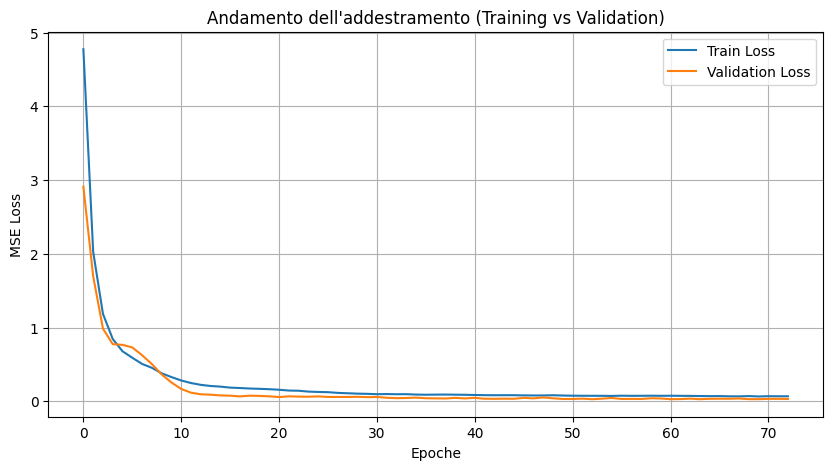

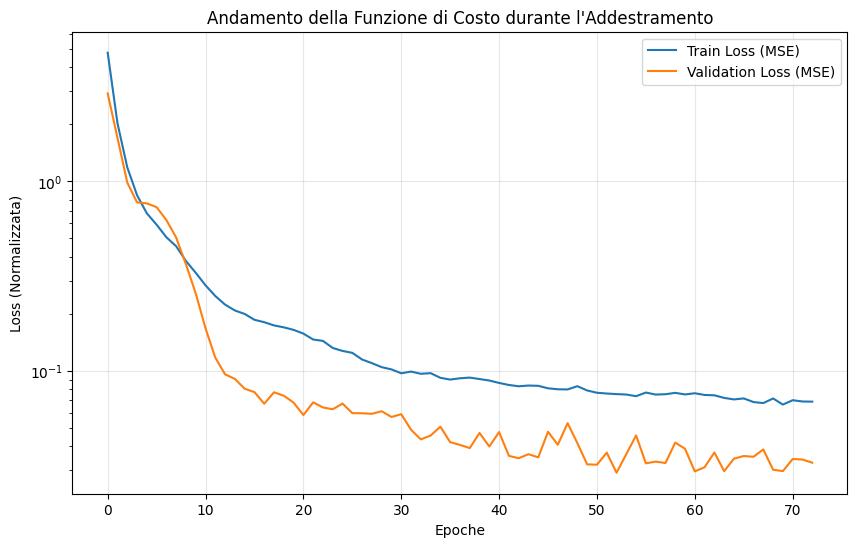

Grafici salvati con successo come 'learning_curves_lineare.png' e 'learning_curves_log.png'!


In [ ]:
# ==============================================================================
# VISUALIZZAZIONE DELLE LEARNING CURVES
# ==============================================================================
print("\nGenerazione dei grafici delle Learning Curves...")

# --- GRAFICO 1: SCALA LINEARE ---
# Mostra la caduta verticale dell'errore nelle prime fasi dell'addestramento.
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('MSE Loss')
plt.title('Andamento dell\'addestramento (Training vs Validation)')
plt.legend()
plt.grid(True)
plt.show()


# --- GRAFICO 2: SCALA LOGARITMICA ---
# "Inrandisce" la fase finale del training. Aiuta a visualizzare se il modello sta ancora limando piccoli errori o se il learning rate è diventato troppo piccolo.
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')
plt.title('Andamento della Funzione di Costo durante l\'Addestramento')
plt.xlabel('Epoche')
plt.ylabel('Loss (Normalizzata)')
plt.yscale('log') # La scala logaritmica aiuta a vedere meglio la discesa finale
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('learning_curves.png', dpi=300)
plt.show()

print("Grafici salvati con successo come 'learning_curves_lineare.png' e 'learning_curves_log.png'!")

**5.2 Quantificazione dell'Incertezza tramite Monte Carlo Dropout**

Un requisito fondamentale per l'impiego di modelli surrogati in ambito clinico è la capacità non solo di fornire una predizione deterministica, ma di associarvi un livello di confidenza. Per quantificare l'incertezza della rete neurale si è adottato il metodo del **Monte Carlo Dropout (MCD)**.

Come introdotto nella Sezione 3, il Dropout viene tradizionalmente impiegato in fase di addestramento come tecnica di regolarizzazione per contrastare l'overfitting, "spegnendo" casualmente una frazione dei neuroni. Di norma, in fase di valutazione, questo meccanismo viene disattivato. Nel MCD, invece, il Dropout viene mantenuto **attivo** anche durante l'inferenza.

La logica operativa seguita è la seguente:
* Per una specifica configurazione angolare e spaziale, si richiedono al modello *N* predizioni (100 iterazioni continue).
* Poiché il Dropout resta attivo, i dati attraversano ogni volta percorsi neurali (sotto-modelli) differenti.
* Si ottiene così una distribuzione statistica delle risposte, dalla quale si estraggono la **media** (la predizione vera e propria) e la **deviazione standard** (l'incertezza epistemica del modello).

Clinicamente, una varianza contenuta indica che i vari "sotto-modelli" concordano sulla stima della dose, suggerendo alta affidabilità. Una varianza elevata, al contrario, segnala scarsa sicurezza (ad esempio per configurazioni geometriche poco rappresentate nel training set).

Infine, un passaggio cruciale di questa sezione è la trasformazione inversa dei dati. Durante il preprocessing, le grandezze fisiche erano state compresse nel dominio logaritmico e standardizzate. Per rendere i risultati intellegibili (in giorni e Gray), è necessario applicare l'esponenziale inverso e l'inversione dello scaler originale alle predizioni.

In [ ]:
# ==============================================================================
# 5.2 INFERENZA CON MONTE CARLO DROPOUT
# ==============================================================================
# Carichiamo i pesi ottimali e forziamo il modello in modalità training.
# ATTENZIONE: Questo serve a mantenere il Dropout ATTIVO durante l'inferenza!
modello.load_state_dict(torch.load('modello_migliore.pth'))
modello.train() # ATTENZIONE: Dropout ATTIVO per MC Dropout!

num_mc_simulations = 100
tutte_le_predizioni = []

print("\nEsecuzione Monte Carlo Dropout sul Test Set...")

# Disattiviamo il motore di calcolo dei gradienti (autograd) per risparmiare memoria e CPU. Il modello deve solo compiere "passaggi in avanti" (forward).

with torch.no_grad():
    for _ in range(num_mc_simulations):

        # 1. Inferenza (i tensori di output sono logaritmici e scalati)
        pred_scaled = modello(X_test_t).cpu().numpy()

        # 2. Inversione dello StandardScaler
        pred_log = scaler_y.inverse_transform(pred_scaled)

        # 3. Inversione della trasformazione logaritmica (esponenziale - 1)
        pred_reale = np.expm1(pred_log)
        tutte_le_predizioni.append(pred_reale)

# Creazione di un array NumPy 3D: (100 simulazioni x campioni di test x 19 output)
tutte_le_predizioni = np.array(tutte_le_predizioni)

# Calcolo delle statistiche sull'ensemble:
test_pred_reale = tutte_le_predizioni.mean(axis=0)
test_pred_std = tutte_le_predizioni.std(axis=0)  # <-- Nuova riga per l'incertezza

# Applichiamo la trasformazione inversa anche ai target fisici (Ground Truth) per consentire un confronto omogeneo e diretto in fase di stampa.
y_test_log = scaler_y.inverse_transform(y_test_t.cpu().numpy())
y_test_reale = np.expm1(y_test_log)
# ==============================================================================
# STAMPA DEI RISULTATI COMPLETI E DELL'INCERTEZZA
# ==============================================================================
print("\n" + "="*85)
print("\n" + "="*85)
print("     RISULTATI COMPLETI SUL TEST SET (Tutte le Simulazioni)")
print("="*85)

organi = ["Cristallino", "Retina", "Cornea", "Nervo Ottico", "Sclera", "Tumore"]
num_test_sims = len(y_test_reale)

for j in range(num_test_sims):
    # Ricostruzione dell'angolo spaziale in gradi per facilitare la lettura
    sin_t = X_test[j][0]
    cos_t = X_test[j][1]
    angolo_rad = np.arctan2(sin_t, cos_t)
    angolo_deg = round((np.degrees(angolo_rad) + 360) % 360)

    print(f"\n--- Previsione per la Simulazione {j+1} (Angolo Placca: {angolo_deg}°) ---")

    # Confronto dei tempi fisici di irraggiamento
    tempo_vero = y_test_reale[j][0]
    tempo_pred = max(0.0, test_pred_reale[j][0]) # Prevenzione di lievi derive negative

    print(f"{'TEMPO (giorni)':<15} | VERO: {tempo_vero:.4f}  |  PREDETTO: {tempo_pred:.4f}")
    print("-" * 85)

    print(f"{'ORGANO':<14} | {'DOSE MEDIA VERA':<17} | {'DOSE MEDIA PRED':<17} | {'DOSE MAX VERA':<15} | {'DOSE MAX PRED'}")
    print("-" * 85)

    for i, organo in enumerate(organi):

        # Mappatura dinamica degli indici per le colonne di output
        idx_media = 1 + (i * 3)
        idx_max   = 1 + (i * 3) + 2

        # Estrazione Valori Reali Fisici
        media_vera = y_test_reale[j][idx_media]
        media_pred = max(0.0, test_pred_reale[j][idx_media])
        media_std  = test_pred_std[j][idx_media] # Incertezza sulla media

        max_vera = y_test_reale[j][idx_max]
        max_pred = max(0.0, test_pred_reale[j][idx_max])
        max_std  = test_pred_std[j][idx_max]     # Incertezza sul massimo

        # Stampa con formattazione: Valore Predetto ± Deviazione Standard
        print(f"{organo:<14} | {media_vera:<17.4f} | {media_pred:>7.4f} ± {media_std:<6.4f} | {max_vera:<15.4f} | {max_pred:>7.4f} ± {max_std:.4f}")

    print("-" * 85)


Esecuzione Monte Carlo Dropout sul Test Set...

     RISULTATI COMPLETI SUL TEST SET (Tutte le Simulazioni)

--- Previsione per la Simulazione 1 (Angolo Placca: 45°) ---
TEMPO (giorni)  | VERO: 7.2747  |  PREDETTO: 8.0760
-------------------------------------------------------------------------------------
ORGANO         | DOSE MEDIA VERA   | DOSE MEDIA PRED   | DOSE MAX VERA   | DOSE MAX PRED
-------------------------------------------------------------------------------------
Cristallino    | 1.1355            |  1.2524 ± 0.3971 | 22.7410         | 23.2311 ± 4.6873
Retina         | 50.1886           | 54.2651 ± 10.4029 | 660.7626        | 666.5603 ± 137.7315
Cornea         | 16.7819           | 17.6967 ± 3.1634 | 987.0326        | 1082.2690 ± 177.1595
Nervo Ottico   | 177.0172          | 170.3541 ± 21.8170 | 389.4284        | 398.7023 ± 45.6106
Sclera         | 113.9716          | 120.5991 ± 24.5914 | 1827.0139       | 2004.1165 ± 391.9618
Tumore         | 28.7266           | 29.482

**5.3 Valutazione Grafica delle Prestazioni (Scatter Plots)**

Per fornire un riscontro visivo e immediato sull'accuratezza del modello a valle dell'inferenza Monte Carlo, i risultati ottenuti sul *Test Set* vengono riassunti tramite grafici a dispersione (*scatter plot*). 

L'analisi si articola su tre metriche fondamentali:
* **Dose Media:** Confronto tra i valori di dose media (reali vs. predetti) per ciascun distretto anatomico.
* **Dose Massima (Hotspot):** Valutazione dei picchi massimi di dose, parametro clinico cruciale per prevenire la necrosi dei tessuti sani.
* **Tempo di Trattamento:** Verifica della predizione sui giorni necessari a erogare la dose prescritta al target tumorale.

In tutti i grafici, la retta bisettrice tratteggiata ($y = x$) rappresenta il locus dei punti ideali, ovvero il caso in cui la predizione della rete neurale coincide perfettamente con il dato fisico della simulazione originale. 
Un aspetto fondamentale di questa visualizzazione è l'inclusione delle barre d'errore verticali: esse rappresentano l'incertezza epistemica (deviazione standard) calcolata tramite il *Monte Carlo Dropout*. Questo elemento grafico permette di valutare simultaneamente l'accuratezza puntuale del modello e il suo livello di confidenza statistica per ogni singola configurazione geometrica.


Generazione dei grafici di valutazione del Test Set in corso...
Grafici riassuntivi salvati con successo come 'scatter_plot_media_test_set.png' e 'scatter_plot_max_test_set.png'!


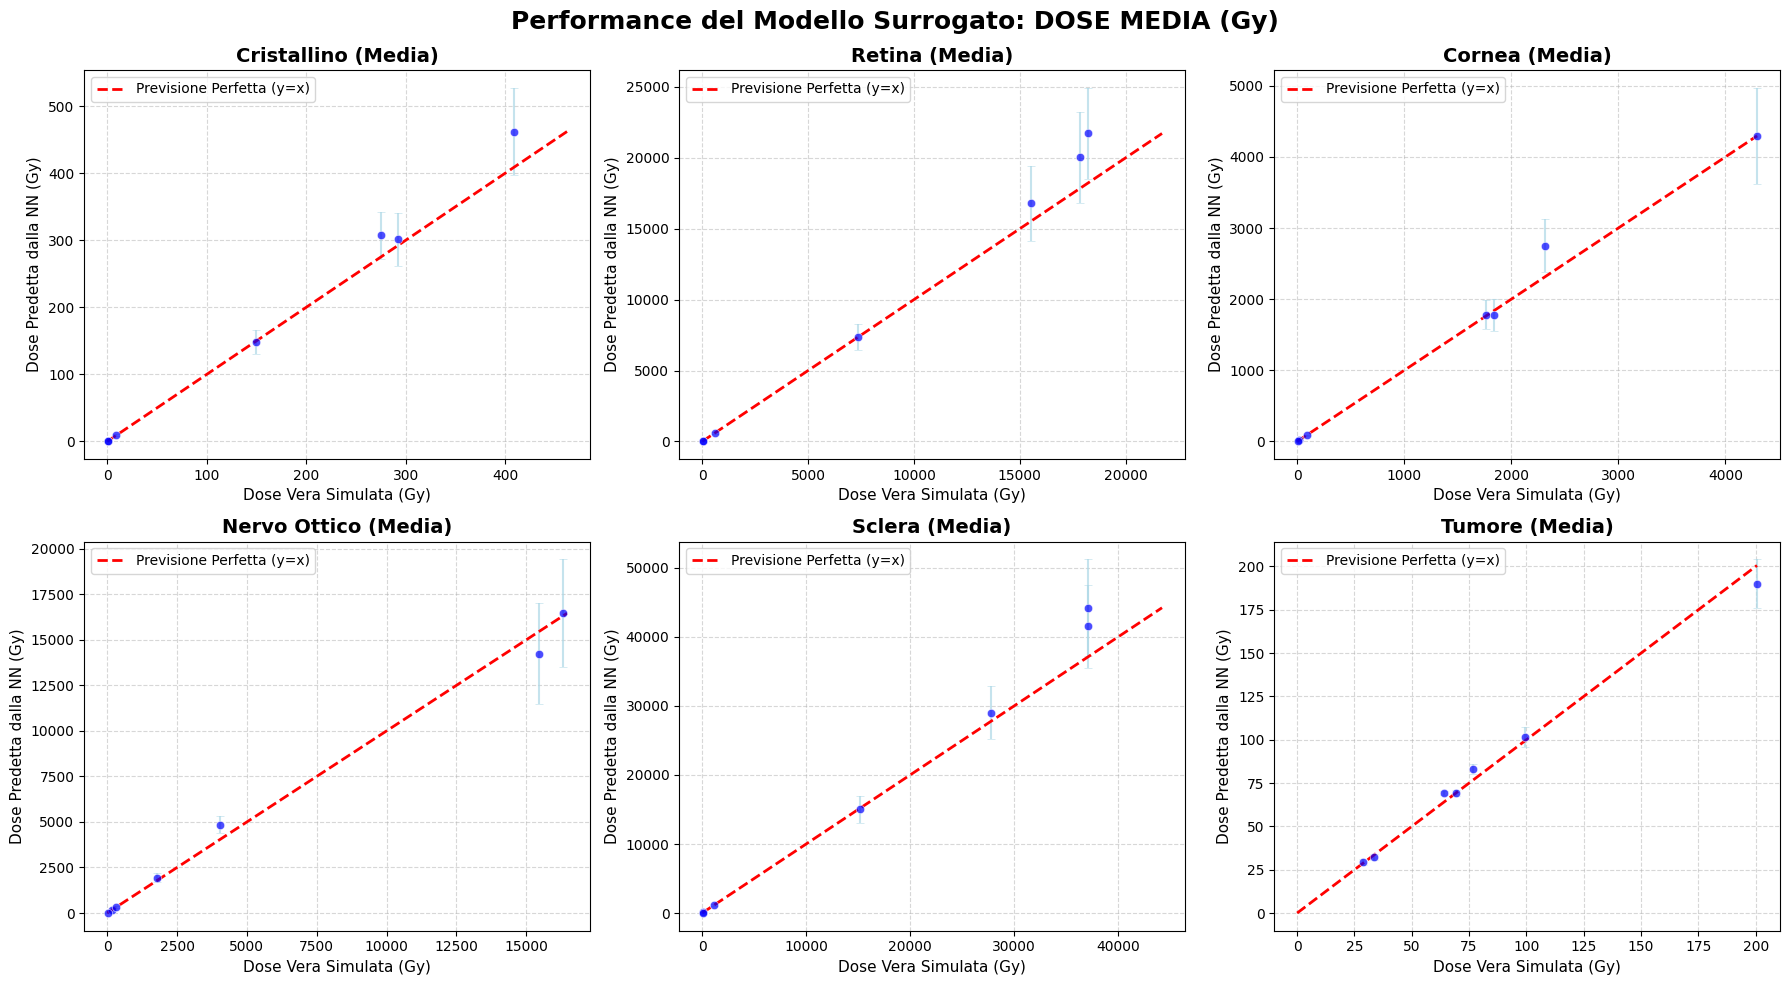

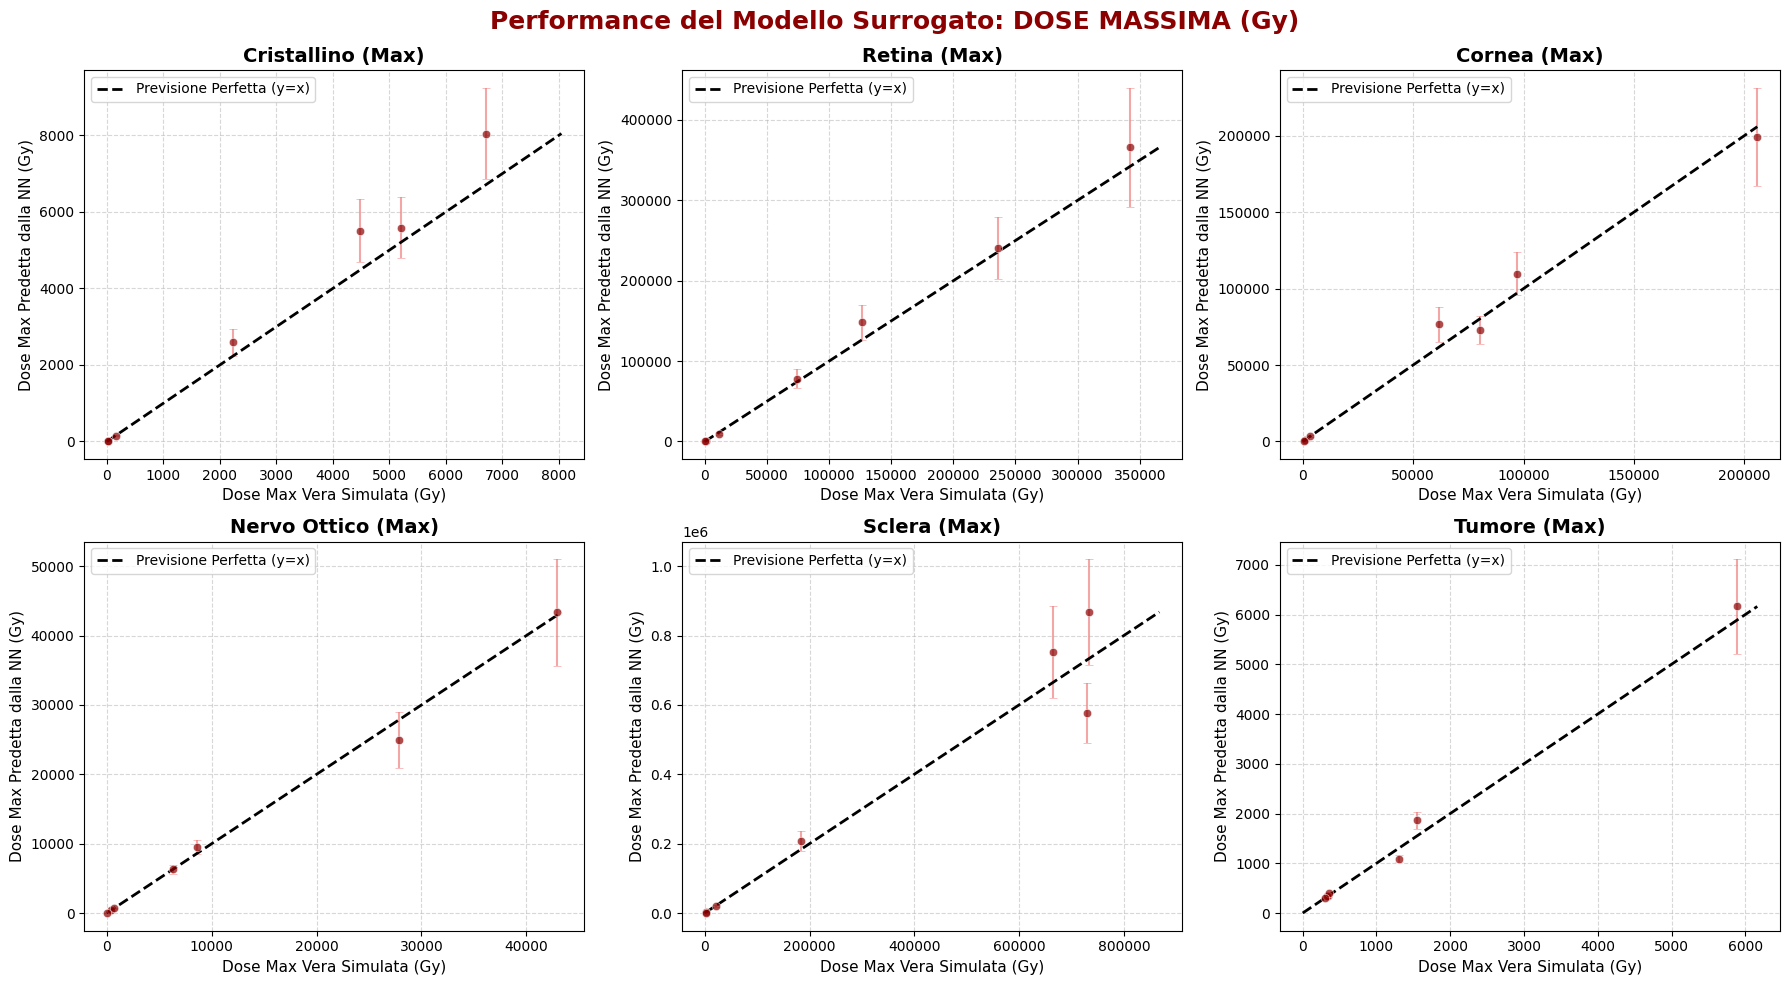

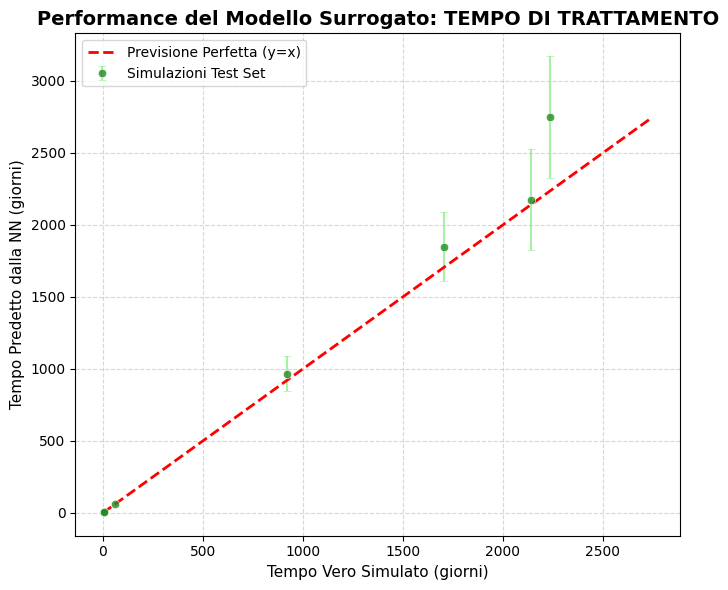

In [ ]:
# ==============================================================================
# 5.3 GENERAZIONE DEI GRAFICI RIASSUNTIVI
# ==============================================================================

organi = ["Cristallino", "Retina", "Cornea", "Nervo Ottico", "Sclera", "Tumore"]

print("\nGenerazione dei grafici di valutazione del Test Set in corso...")

# ==============================================================================
# GRAFICO 1: DOSE MEDIA
# ==============================================================================
fig_med, axes_med = plt.subplots(2, 3, figsize=(18, 10))
fig_med.suptitle("Performance del Modello Surrogato: DOSE MEDIA (Gy)", fontsize=18, fontweight='bold')
axes_med = axes_med.flatten()

for i, organo in enumerate(organi):
    # Mappatura indici: la colonna 0 è il tempo. Ogni organo ha 3 feature.
    # L'indice della Dose Media è 1 + (i * 3)
    idx_media = 1 + (i * 3)

    dosi_vere = y_test_reale[:, idx_media]
    dosi_predette = test_pred_reale[:, idx_media]

    ax = axes_med[i]

    # Scatter plot con barre d'errore (Incertezza Epistemica derivata da MCD)
    ax.errorbar(dosi_vere, dosi_predette, yerr=test_pred_std[:, idx_media],
                fmt='o', color='blue', ecolor='lightblue', elinewidth=1.5,
                capsize=3, alpha=0.7, markeredgecolor='white', markeredgewidth=0.5)

    # Tracciamento della bisettrice (Previsione Perfetta y = x)
    min_val = min(0.0, min(dosi_vere.min(), dosi_predette.min()))
    max_val = max(dosi_vere.max(), dosi_predette.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsione Perfetta (y=x)')

    # Formattazione del singolo subplot
    ax.set_title(f'{organo} (Media)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dose Vera Simulata (Gy)', fontsize=11)
    ax.set_ylabel('Dose Predetta dalla NN (Gy)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
fig_med.subplots_adjust(top=0.92) # Lascia spazio per il titolo globale
plt.savefig('scatter_plot_media_test_set.png', dpi=300)

# ==============================================================================
# GRAFICO 2: DOSE MASSIMA (HOTSPOT)
# ==============================================================================
fig_max, axes_max = plt.subplots(2, 3, figsize=(18, 10))
fig_max.suptitle("Performance del Modello Surrogato: DOSE MASSIMA (Gy)", fontsize=18, fontweight='bold', color='darkred')
axes_max = axes_max.flatten()

for i, organo in enumerate(organi):
    # L'indice della Dose Massima è 1 + (i * 3) + 2
    idx_max = 1 + (i * 3) + 2

    dosi_vere_max = y_test_reale[:, idx_max]
    dosi_predette_max = test_pred_reale[:, idx_max]

    ax = axes_max[i]

    # Scatter plot (rosso per evidenziare visivamente il concetto di hotspot)
    ax.errorbar(dosi_vere_max, dosi_predette_max, yerr=test_pred_std[:, idx_max],
                fmt='o', color='darkred', ecolor='lightcoral', elinewidth=1.5,
                capsize=3, alpha=0.7, markeredgecolor='white', markeredgewidth=0.5)

    # Bisettrice
    min_val = min(0.0, min(dosi_vere_max.min(), dosi_predette_max.min()))
    max_val = max(dosi_vere_max.max(), dosi_predette_max.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Previsione Perfetta (y=x)')

    # Formattazione
    ax.set_title(f'{organo} (Max)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dose Max Vera Simulata (Gy)', fontsize=11)
    ax.set_ylabel('Dose Max Predetta dalla NN (Gy)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
fig_max.subplots_adjust(top=0.92)
plt.savefig('scatter_plot_max_test_set.png', dpi=300)

print("Grafici riassuntivi salvati con successo come 'scatter_plot_media_test_set.png' e 'scatter_plot_max_test_set.png'!")

# ==============================================================================
# GRAFICO 3: TEMPO DI TRATTAMENTO (GIORNI)
# ==============================================================================
plt.figure(figsize=(7, 6))

tempo_vero = y_test_reale[:, 0]
tempo_predetto = test_pred_reale[:, 0]
tempo_std = test_pred_std[:, 0]

# Scatter plot con barre d'errore 
plt.errorbar(tempo_vero, tempo_predetto, yerr=tempo_std,
             fmt='o', color='forestgreen', ecolor='lightgreen', elinewidth=1.5,
             capsize=3, alpha=0.8, markeredgecolor='white', markeredgewidth=0.5,
             label='Simulazioni Test Set')

# Tracciamento della bisettrice (Previsione Perfetta y = x)
min_val = min(0.0, min(tempo_vero.min(), tempo_predetto.min()))
max_val = max(tempo_vero.max(), tempo_predetto.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsione Perfetta (y=x)')

# Formattazione del singolo subplot
plt.title("Performance del Modello Surrogato: TEMPO DI TRATTAMENTO", fontsize=14, fontweight='bold')
plt.xlabel('Tempo Vero Simulato (giorni)', fontsize=11)
plt.ylabel('Tempo Predetto dalla NN (giorni)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig('scatter_plot_tempo_test_set.png', dpi=300)

# Mostra i grafici a schermo
plt.show()

**5.4 Esame Finale dei Risultati dell'Algoritmo (Metriche di Errore)**

In questa sezione finale, dedicata alla conclusione della Task 1, viene quantificata in modo formale la deviazione tra le predizioni dell'algoritmo e le simulazioni reali sul *Test Set*. 

Invece di eseguire una singola inferenza deterministica (a Dropout spento), si è scelto di valutare l'errore direttamente sulla stima media derivata dal Monte Carlo Dropout calcolata nella sezione precedente. In ambito probabilistico, infatti, la media dell'ensemble (*Expected Value*) rappresenta la stima più robusta e generalizzabile del modello.

Per fornire una valutazione completa, vengono calcolate due metriche:
* **MAE (Mean Absolute Error):** Esprime l'errore medio assoluto nelle unità di misura originali (Gray per le dosi, giorni per il tempo).
* **MAPE (Mean Absolute Percentage Error):** Standardizza l'errore in termini percentuali rispetto al valore reale, permettendo di stimare la "gravità" relativa dell'imprecisione. 

La formula matematica per il MAPE è definita come segue:

$$\text{MAPE} = \left\lvert \frac{D_{\text{pred}}-D_{\text{reale}}}{D_{\text{reale}}} \right\rvert \times 100$$

              TABELLA VALUTAZIONE METRICHE TEST SET             
                 Feature        MAE  MAPE (%)
          Tempo (giorni)   104.8692    8.7483
Cristallino - Media (Gy)    13.8888    8.1601
  Cristallino - Std (Gy)     0.3691   31.0017
  Cristallino - Max (Gy)   448.2862   12.4888
     Retina - Media (Gy)   998.8365    7.7525
       Retina - Std (Gy)     5.1729   28.2384
       Retina - Max (Gy)  8041.7476    8.7816
     Cornea - Media (Gy)    73.4811    5.8330
       Cornea - Std (Gy)     3.4920   20.0312
       Cornea - Max (Gy)  5967.6616   15.0827
  Nervo Opt - Media (Gy)   336.6325    8.5972
    Nervo Opt - Std (Gy)    46.5295   27.0571
    Nervo Opt - Max (Gy)   624.8920    6.4073
     Sclera - Media (Gy)  1857.4932    6.7275
       Sclera - Std (Gy)     7.1571   28.9998
       Sclera - Max (Gy) 57454.5391   15.4680
     Tumore - Media (Gy)     3.7251    4.2091
       Tumore - Std (Gy)     0.4999   29.9378
       Tumore - Max (Gy)   122.9041    8.4698
MAE Medio Globa

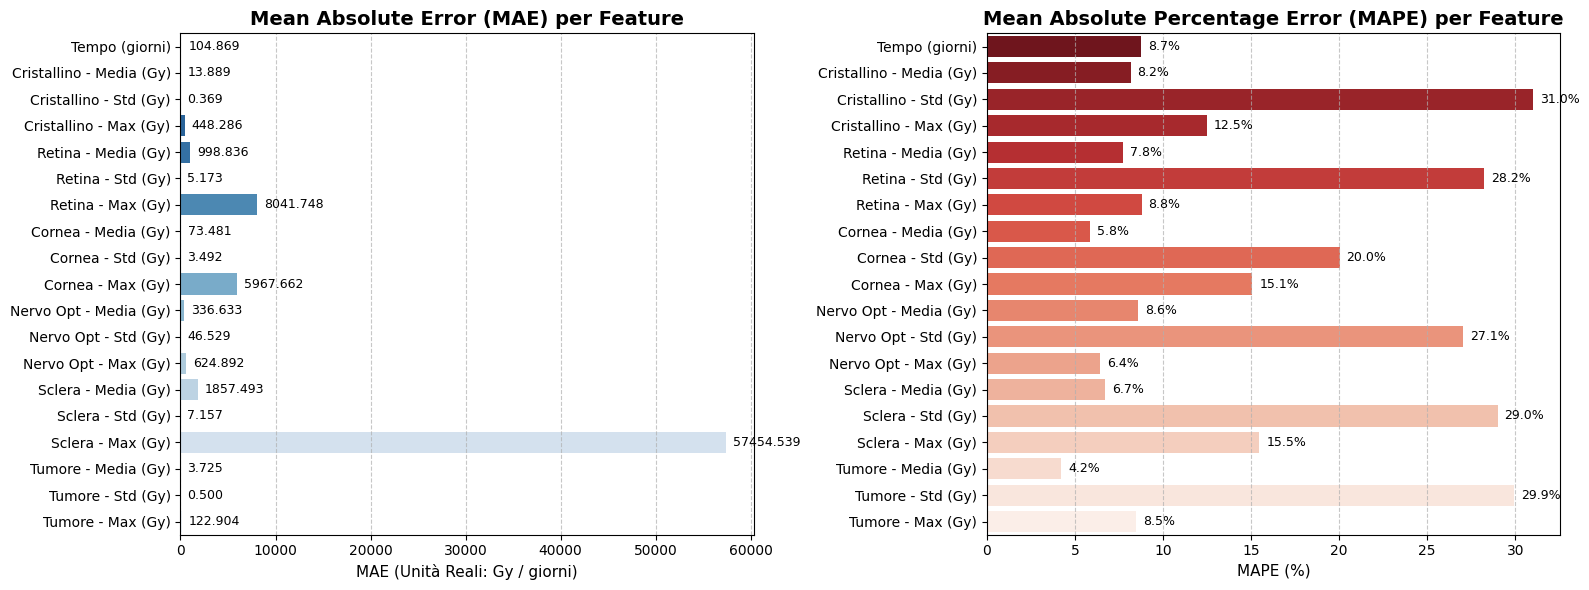

In [ ]:


# ==============================================================================
# 5.4 CALCOLO DELLE METRICHE GLOBALI (MAE e MAPE)
# ==============================================================================

# Definizione delle etichette descrittive per i 19 output fisici
nomi_output = [
    "Tempo (giorni)",
    "Cristallino - Media (Gy)", "Cristallino - Std (Gy)", "Cristallino - Max (Gy)",
    "Retina - Media (Gy)",      "Retina - Std (Gy)",      "Retina - Max (Gy)",
    "Cornea - Media (Gy)",      "Cornea - Std (Gy)",      "Cornea - Max (Gy)",
    "Nervo Opt - Media (Gy)",   "Nervo Opt - Std (Gy)",   "Nervo Opt - Max (Gy)",
    "Sclera - Media (Gy)",      "Sclera - Std (Gy)",      "Sclera - Max (Gy)",
    "Tumore - Media (Gy)",      "Tumore - Std (Gy)",      "Tumore - Max (Gy)"
]

# Calcolo degli errori feature per feature sfruttando le funzioni di scikit-learn
# L'argomento 'raw_values' restituisce l'errore separato per ciascuna delle 19 colonne
mae_per_feature = mean_absolute_error(y_test_reale, test_pred_reale, multioutput='raw_values')

# Il MAPE viene moltiplicato per 100 per convertirlo in un valore percentuale leggibile
mape_per_feature = mean_absolute_percentage_error(y_test_reale, test_pred_reale, multioutput='raw_values') * 100

# Aggregazione dei risultati in un DataFrame Pandas per una formattazione tabulare pulita
df_metriche = pd.DataFrame({
    'Feature': nomi_output,
    'MAE': mae_per_feature,
    'MAPE (%)': mape_per_feature
})

# Stampa riassuntiva in console
print("="*65)
print("              TABELLA VALUTAZIONE METRICHE TEST SET             ")
print("="*65)
print(df_metriche.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*65)
print(f"MAE Medio Globale:  {np.mean(mae_per_feature):.4f}")
print(f"MAPE Medio Globale: {np.mean(mape_per_feature):.2f}%")
print("="*65)


# ==============================================================================
# GENERAZIONE DEI GRAFICI A BARRE (VISUALIZZAZIONE METRICHE)
# ==============================================================================

plt.figure(figsize=(16, 6))

# --- Grafico 1: Distribuzione del MAE ---
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=df_metriche, x='MAE', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Mean Absolute Error (MAE) per Feature', fontsize=14, fontweight='bold')
plt.xlabel('MAE (Unità Reali: Gy / giorni)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Etichettatura automatica dei valori sopra le singole barre
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'{width:.3f}', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

# --- Grafico 2: Distribuzione del MAPE ---
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=df_metriche, x='MAPE (%)', y='Feature', hue='Feature', palette='Reds_r', legend=False)
plt.title('Mean Absolute Percentage Error (MAPE) per Feature', fontsize=14, fontweight='bold')
plt.xlabel('MAPE (%)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Etichettatura percentuale
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

# 6. Task 2: Ottimizzazione della posizione della placca 

In questa sezione viene sviluppata e analizzata la seconda fase (Task 2) del progetto. L'obiettivo è ottimizzare la posizione angolare della placca brachiterapica sfruttando le predizioni ultra-rapide fornite dal modello surrogato appena validato. L'analisi si articola nelle seguenti fasi concettuali:

1. **Definizione dello spazio di ricerca:** Le simulazioni esplorano il movimento della placca sull'intera circonferenza oculare, con spostamenti angolari discreti di $\Delta\theta = 5^\circ$ nel range $[0^\circ, 355^\circ]$. Viene generato un array di angoli, opportunamente convertiti in radianti per compatibilità con le funzioni goniometriche di input ($\sin$ e $\cos$).
2. **Inferenza e Post-processing:** Le feature vettoriali generate vengono scalate e passate al modello in modalità valutazione (`torch.no_grad()`). Le predizioni in output vengono poi riconvertite nella scala fisica originale invertendo la trasformazione logaritmica applicata in fase di preprocessing, garantendo un'immediata interpretabilità clinica.
3. **Definizione della regione ammissibile:** L'obiettivo primario è individuare una configurazione che rispetti rigorosamente i vincoli clinici. A tale scopo, vengono applicate maschere booleane per filtrare lo spazio delle soluzioni: una configurazione è ammissibile solo se soddisfa contemporaneamente le soglie di tolleranza radiobiologica sulla dose media degli Organi A Rischio (OAR) e il limite massimo per la durata del trattamento ($T < 7 \text{ giorni}$).
4. **Definizione della posizione ottimale:** All'interno della regione ammissibile, la configurazione migliore è definita come quella che minimizza il rischio cumulativo legato ai picchi di dose sugli OAR. Matematicamente, si minimizza la seguente funzione obiettivo adimensionale:
   $$f(\theta) = \sum_{k \in \text{OAR}} \text{Dose}_{\max, k}(\theta)$$

In [44]:
# ==============================================================================
# TASK 2: OTTIMIZZAZIONE DELLA POSIZIONE DELLA PLACCA (INFERENCE & FILTERING)
# ==============================================================================
print("\n" + "="*85)
print("   TASK 2: RICERCA DELLA POSIZIONE OTTIMALE (VINCOLI CLINICI)")
print("="*85)

# 1. Spazio di ricerca: 72 angoli da 0° a 355° (passo 5°)
angoli_gradi  = np.arange(0, 360, 5)
angoli_rad    = np.radians(angoli_gradi)
numero_angoli = len(angoli_gradi)

# Feature di input: phi = 0, raggio costante nel dataset (mean == valore di training)
phi_rad      = 0.0
raggio_medio = X[:, 4].mean()

X_opt = np.zeros((numero_angoli, 5))
X_opt[:, 0] = np.sin(angoli_rad)
X_opt[:, 1] = np.cos(angoli_rad)
X_opt[:, 2] = np.sin(phi_rad)
X_opt[:, 3] = np.cos(phi_rad)
X_opt[:, 4] = raggio_medio

# 2. Forward pass deterministico (modello in eval, Dropout disattivo)
X_opt_scaled = scaler_X.transform(X_opt).astype('float32')
X_opt_t      = torch.tensor(X_opt_scaled).to(device)

modello.eval()
with torch.no_grad():
    pred_scaled_opt = modello(X_opt_t).cpu().numpy()

pred_log_opt   = scaler_y.inverse_transform(pred_scaled_opt)
pred_reale_opt = np.expm1(pred_log_opt)

# 3. Metriche per organo
tempo_opt        = pred_reale_opt[:, 0]
crist_media_opt  = pred_reale_opt[:, 1]
retina_media_opt = pred_reale_opt[:, 4]
cornea_media_opt = pred_reale_opt[:, 7]
nervo_media_opt  = pred_reale_opt[:, 10]
sclera_media_opt = pred_reale_opt[:, 13]

crist_max_opt  = pred_reale_opt[:, 3]
retina_max_opt = pred_reale_opt[:, 6]
cornea_max_opt = pred_reale_opt[:, 9]
nervo_max_opt  = pred_reale_opt[:, 12]
sclera_max_opt = pred_reale_opt[:, 15]

# ==============================================================================
# SCORE SULLA DOSE MASSIMA — normalizzato, non pesato
# ==============================================================================
#   Ogni dose max viene divisa per la propria scala L_max = 1.5 * limite clinico.
#   Il risultato è adimensionale: nessun organo domina per scala assoluta e,
#   a parità di "quanto stai riempiendo il tetto", ogni OAR pesa uguale.
#       S(theta) = sum_k  D_max,k(theta) / (1.5 * L_k)
#   Identico allo score usato nel modello a splitting continuo.
# ==============================================================================

LIMITE_MEDIA = {                 # limiti clinici sulla dose MEDIA (Gy)
    'crist':   5.0,
    'retina': 45.0,
    'cornea': 50.0,
    'nervo':  55.0,
    'sclera': 100.0,
}
FATTORE_MAX = 1.5                # scala convenzionale per le dosi massime
LIMITE_MAX  = {k: FATTORE_MAX * v for k, v in LIMITE_MEDIA.items()}

score_max_oar = (
    crist_max_opt  / LIMITE_MAX['crist']  +
    retina_max_opt / LIMITE_MAX['retina'] +
    cornea_max_opt / LIMITE_MAX['cornea'] +
    nervo_max_opt  / LIMITE_MAX['nervo']  +
    sclera_max_opt / LIMITE_MAX['sclera']
)

# 4. Filtro clinico (vincoli hard sulla dose MEDIA)
maschera_vincoli = (
    (tempo_opt        < 7.0)   &
    (crist_media_opt  < 5.0)   &
    (retina_media_opt < 45.0)  &
    (cornea_media_opt < 50.0)  &
    (nervo_media_opt  < 55.0)  &
    (sclera_media_opt < 100.0)
)

angoli_validi = angoli_gradi[maschera_vincoli]

# 5. Selezione del migliore tra gli angoli validi
if len(angoli_validi) == 0:
    print("\n[!] Nessun angolo soddisfa tutti i limiti clinici.")
else:
    print(f"\n{len(angoli_validi)} angoli rispettano i vincoli clinici.")

    df_validi = pd.DataFrame({
        'Angolo (°)':      angoli_validi,
        'Tempo (gg)':      tempo_opt[maschera_vincoli],
        'Crist. Med (Gy)': crist_media_opt[maschera_vincoli],
        'Retina Med (Gy)': retina_media_opt[maschera_vincoli],
        'Cornea Med (Gy)': cornea_media_opt[maschera_vincoli],
        'Nervo Med (Gy)':  nervo_media_opt[maschera_vincoli],
        'Sclera Med (Gy)': sclera_media_opt[maschera_vincoli],
        'Score Max OAR':   score_max_oar[maschera_vincoli]
    })

    df_ordinato     = df_validi.sort_values(by='Score Max OAR').reset_index(drop=True)
    migliore_angolo = df_ordinato.iloc[0]

    print("\n" + "*"*85)
    print(f"   MIGLIOR CONFIGURAZIONE: {int(migliore_angolo['Angolo (°)'])}°")
    print("*"*85)
    print(f"  Tempo di trattamento    : {migliore_angolo['Tempo (gg)']:.2f} giorni")
    print(f"  Dose Media Cristallino  : {migliore_angolo['Crist. Med (Gy)']:.2f} Gy  (limite: 5 Gy)")
    print(f"  Dose Media Retina       : {migliore_angolo['Retina Med (Gy)']:.2f} Gy  (limite: 45 Gy)")
    print(f"  Dose Media Cornea       : {migliore_angolo['Cornea Med (Gy)']:.2f} Gy  (limite: 50 Gy)")
    print(f"  Dose Media Nervo Ottico : {migliore_angolo['Nervo Med (Gy)']:.2f} Gy  (limite: 55 Gy)")
    print(f"  Dose Media Sclera       : {migliore_angolo['Sclera Med (Gy)']:.2f} Gy  (limite: 100 Gy)")
    print(f"  Score Max OAR           : {migliore_angolo['Score Max OAR']:.3f}")
    print("*"*85)

    print(f"\nMigliori {len(angoli_validi)} configurazioni valide (Score Max OAR crescente):")
    print(df_ordinato.head(14).to_string(index=False))



   TASK 2: RICERCA DELLA POSIZIONE OTTIMALE (VINCOLI CLINICI)

8 angoli rispettano i vincoli clinici.

*************************************************************************************
   MIGLIOR CONFIGURAZIONE: 0°
*************************************************************************************
  Tempo di trattamento    : 6.38 giorni
  Dose Media Cristallino  : 0.56 Gy  (limite: 5 Gy)
  Dose Media Retina       : 27.98 Gy  (limite: 45 Gy)
  Dose Media Cornea       : 2.35 Gy  (limite: 50 Gy)
  Dose Media Nervo Ottico : 9.12 Gy  (limite: 55 Gy)
  Dose Media Sclera       : 48.47 Gy  (limite: 100 Gy)
  Score Max OAR           : 11.137
*************************************************************************************

Migliori 8 configurazioni valide (Score Max OAR crescente):
 Angolo (°)  Tempo (gg)  Crist. Med (Gy)  Retina Med (Gy)  Cornea Med (Gy)  Nervo Med (Gy)  Sclera Med (Gy)  Score Max OAR
          0    6.381226         0.556147        27.976091         2.353446        

Il limite della *Grid Search* precedente risiede nella sua natura discreta: l'ottimo globale potrebbe trovarsi in un punto intermedio tra i passi di $5^\circ$ testati. Poiché la rete neurale sviluppata è una funzione interamente differenziabile, è possibile trattare l'angolo $\theta$ come un parametro ottimizzabile (attivando `requires_grad=True`) e lasciare che l'algoritmo di Backpropagation trovi il minimo esatto della funzione di costo. 

Per tradurre i "vincoli hard" della Grid Search in un problema di ottimizzazione continua, la *Loss Clinica* è stata formulata integrando penalità morbide (funzioni ReLU quadratiche) che si attivano e generano forti gradienti repulsivi solo se le soglie cliniche vengono superate. Infine, per mitigare il rischio di convergenza verso minimi locali, viene implementata una strategia *Multi-Start* partendo da 4 diverse angolazioni iniziali.

In [ ]:
# ==============================================================================
# TASK 2: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING - MULTI START)
# ==============================================================================

print("\n" + "=" * 85)
print("   TASK 2: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING)")
print("=" * 85)

# 1. Congeliamo i pesi del modello surrogato
modello.eval()
for param in modello.parameters():
    param.requires_grad = False

# 2. Parametri clinici e limiti di scala
PHI_RAD = 0.0
RAGGIO_MEDIO = float(X[:, 4].mean())

# Limiti sulla dose MEDIA (Gy) e costante di scala per la dose MAX
LIMITE_MEDIA = {
    'crist':  5.0,
    'retina': 45.0,
    'cornea': 50.0,
    'nervo':  55.0,
    'sclera': 100.0,
}
FATTORE_MAX = 1.5

# Pre-convertiamo medie e scale per PyTorch
mean_X = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
scale_X = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
mean_y = torch.tensor(scaler_y.mean_, dtype=torch.float32, device=device)
scale_y = torch.tensor(scaler_y.scale_, dtype=torch.float32, device=device)


# 3. DEFINIZIONE DELLA LOSS CLINICA (Con Score Normalizzato e Penalità)
def calcola_loss_clinica(pred_reale):
    tempo = pred_reale[0, 0]

    # Dosi Medie per il filtro/penalità
    crist_med  = pred_reale[0, 1]
    retina_med = pred_reale[0, 4]
    cornea_med = pred_reale[0, 7]
    nervo_med  = pred_reale[0, 10]
    sclera_med = pred_reale[0, 13]

    # SCORE NORMALIZZATO SULLE DOSI MASSIME (Adimensionale)
    score_max_oar = (
        pred_reale[0, 3]  / (FATTORE_MAX * LIMITE_MEDIA['crist'])  +
        pred_reale[0, 6]  / (FATTORE_MAX * LIMITE_MEDIA['retina']) +
        pred_reale[0, 9]  / (FATTORE_MAX * LIMITE_MEDIA['cornea']) +
        pred_reale[0, 12] / (FATTORE_MAX * LIMITE_MEDIA['nervo'])  +
        pred_reale[0, 15] / (FATTORE_MAX * LIMITE_MEDIA['sclera'])
    )

    # Penalità morbide (ReLU quadratico): si attivano solo se si supera la soglia clinica
    penalty_tempo  = torch.relu(tempo - 7.0) ** 2
    penalty_crist  = torch.relu(crist_med - LIMITE_MEDIA['crist']) ** 2
    penalty_retina = torch.relu(retina_med - LIMITE_MEDIA['retina']) ** 2
    penalty_cornea = torch.relu(cornea_med - LIMITE_MEDIA['cornea']) ** 2
    penalty_nervo  = torch.relu(nervo_med - LIMITE_MEDIA['nervo']) ** 2
    penalty_sclera = torch.relu(sclera_med - LIMITE_MEDIA['sclera']) ** 2

    # Loss totale: Minimizzo lo Score adimensionale + Penalizzo pesantemente le violazioni
    loss_totale = (
        score_max_oar
        + 1000.0 * (
            penalty_tempo
            + penalty_crist
            + penalty_retina
            + penalty_cornea
            + penalty_nervo
            + penalty_sclera
        )
    )

    return loss_totale, score_max_oar


# ==============================================================================
# INIZIO MULTI-START OPTIMIZATION
# ==============================================================================
punti_partenza_deg = [0.0, 90.0, 180.0, 270.0]
miglior_loss_assoluta = float('inf')
ottimo_assoluto_deg = None
predizioni_ottime = None

print("Inizio ottimizzazione differenziabile multi-start...")

for start_deg in punti_partenza_deg:
    # Definiamo l'angolo theta di partenza
    theta_param = torch.tensor(
        [np.radians(start_deg)],
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )
    optimizer_plaque = optim.Adam([theta_param], lr=0.05)

    num_steps = 300
    for step in range(num_steps):
        optimizer_plaque.zero_grad()

        sin_t = torch.sin(theta_param)
        cos_t = torch.cos(theta_param)
        sin_p = torch.tensor([np.sin(PHI_RAD)], dtype=torch.float32, device=device)
        cos_p = torch.tensor([np.cos(PHI_RAD)], dtype=torch.float32, device=device)
        r_val = torch.tensor([RAGGIO_MEDIO], dtype=torch.float32, device=device)

        x_input = torch.cat([sin_t, cos_t, sin_p, cos_p, r_val]).unsqueeze(0).float()
        x_input_scaled = (x_input - mean_X) / scale_X

        # Forward pass
        pred_scaled = modello(x_input_scaled)
        pred_log = (pred_scaled * scale_y) + mean_y
        pred_reale = torch.expm1(pred_log)

        loss, score_max = calcola_loss_clinica(pred_reale)
        loss.backward()
        optimizer_plaque.step()

    loss_finale = loss.item()
    angolo_trovato = (np.degrees(theta_param.item()) % 360 + 360) % 360

    print(
        f"  └ Start da {start_deg:3.0f}° ➔ Angolo Trovato: {angolo_trovato:6.2f}° | Loss Final: {loss_finale:.4f}"
    )

    if loss_finale < miglior_loss_assoluta:
        miglior_loss_assoluta = loss_finale
        ottimo_assoluto_deg = angolo_trovato
        predizioni_ottime = pred_reale.detach().cpu().numpy()

# 6. Risultato Finale
print("\n" + "*" * 85)
print(
    f"MIGLIOR ANGOLO GLOBALE TROVATO (MULTI-START): {ottimo_assoluto_deg:.2f}°"
)
print(f"    Loss Clinica Totale: {miglior_loss_assoluta:.4f}")

# Stampa delle metriche nella posizione ottimale trovata
print("\n[ METRICHE CLINICHE PREDETTE ALL'ANGOLO OTTIMALE ]")
print(f"Tempo di trattamento   : {predizioni_ottime[0, 0]:.2f} giorni")
print(f"Dose Media Cristallino : {predizioni_ottime[0, 1]:.2f} Gy (limite: 5 Gy)")
print(f"Dose Media Retina      : {predizioni_ottime[0, 4]:.2f} Gy (limite: 45 Gy)")
print(f"Dose Media Cornea      : {predizioni_ottime[0, 7]:.2f} Gy (limite: 50 Gy)")
print(f"Dose Media Nervo Ott.  : {predizioni_ottime[0, 10]:.2f} Gy (limite: 55 Gy)")
print(f"Dose Media Sclera      : {predizioni_ottime[0, 13]:.2f} Gy (limite: 100 Gy)")
print("*" * 85)


   TASK 2: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING)
Inizio ottimizzazione differenziabile multi-start...
  └ Start da   0° ➔ Angolo Trovato: 359.52° | Loss Final: 11.1062
  └ Start da  90° ➔ Angolo Trovato:  55.40° | Loss Final: 56727208.0000
  └ Start da 180° ➔ Angolo Trovato: 179.35° | Loss Final: 627364724736.0000
  └ Start da 270° ➔ Angolo Trovato: 307.97° | Loss Final: 57721188.0000

*************************************************************************************
MIGLIOR ANGOLO GLOBALE TROVATO (MULTI-START): 359.52°
    Loss Clinica Totale: 11.1062

[ METRICHE CLINICHE PREDETTE ALL'ANGOLO OTTIMALE ]
Tempo di trattamento   : 6.38 giorni
Dose Media Cristallino : 0.56 Gy (limite: 5 Gy)
Dose Media Retina      : 27.99 Gy (limite: 45 Gy)
Dose Media Cornea      : 2.33 Gy (limite: 50 Gy)
Dose Media Nervo Ott.  : 8.85 Gy (limite: 55 Gy)
Dose Media Sclera      : 48.43 Gy (limite: 100 Gy)
******************************************************************************

# 7. Task 3: Ottimizzazione robusta della posizione della placca tramite Monte Carlo Dropout

Nella Task 2, appena discussa in dettaglio, l'obiettivo primario era individuare la posizione ottimale della placca. In quest'ultima fase del progetto, si vuole espandere l'analisi quantificando il livello di stabilità della soluzione trovata. A tale scopo, si integra la stima dell'incertezza del modello – attraverso il framework del Monte Carlo Dropout – direttamente nel processo di estrazione della configurazione ottimale.

Affidarsi a una singola iterazione deterministica espone al rischio di selezionare configurazioni sub-ottimali o eccessivamente sensibili al rumore di modellizzazione, dove una minima perturbazione potrebbe rendere la configurazione clinicamente inaccettabile. Per garantire la robustezza della scelta, l'algoritmo ripete le operazioni di ottimizzazione per $N = 1000$ volte, seguendo questa logica:

1. **Attivazione del modello in modalità stocastica:** Il modello viene impostato in modalità `.train()` per mantenere attivo il Dropout (con probabilità $p$). In questa prima fase basata su Grid Search, si utilizza contestualmente `torch.no_grad()` per evitare il ricalcolo dei gradienti, mantenendo l'esecuzione computazionalmente leggera.
2. **Campionamento della distribuzione a posteriori:** L'attivazione del Dropout durante l'inferenza equivale a campionare $N$ reti neurali leggermente diverse tra loro, estratte da una distribuzione di probabilità a posteriori $p(\mathbf{W}|D)$, dove $\mathbf{W}$ rappresenta i pesi della rete e $D$ il dataset di addestramento.
3. **Frequenza di ottimalità e confidenza:** Per ciascuna iterazione vengono ripetute le operazioni di filtraggio e selezione della posizione migliore. Il risultato definitivo dell'analisi è definito come la *moda* della distribuzione, ovvero il valore angolare che si è presentato come ottimale con la maggiore frequenza. Questo approccio permette di definire la percentuale di "vittorie" rispetto al totale delle iterazioni come l'**indice di confidenza statistica** del piano di trattamento.

In [34]:
# ==============================================================================
# TASK 3: OTTIMIZZAZIONE ROBUSTA TRAMITE MONTE CARLO DROPOUT (1000 ITERAZIONI)
# ==============================================================================
print("\n" + "=" * 85)
print("   TASK 3: OTTIMIZZAZIONE ROBUSTA (1000 ITERAZIONI)")
print("=" * 85)

n_iterazioni = 1000
migliori_angoli_storico = []

# 1. Limiti clinici per la normalizzazione dello score
LIMITE_MEDIA = {
    'crist': 5.0,
    'retina': 45.0,
    'cornea': 50.0,
    'nervo': 55.0,
    'sclera': 100.0,
}
FATTORE_MAX = 1.5
LIMITE_MAX = {k: FATTORE_MAX * v for k, v in LIMITE_MEDIA.items()}

# 2. Creazione dello Spazio di Ricerca Fisso
angoli_gradi = np.arange(0, 360, 5)
numero_angoli = len(angoli_gradi)
angoli_rad = np.radians(angoli_gradi)
phi_rad = 0.0
raggio_medio = X[:, 4].mean()

X_opt = np.zeros((numero_angoli, 5))
X_opt[:, 0] = np.sin(angoli_rad)
X_opt[:, 1] = np.cos(angoli_rad)
X_opt[:, 2] = np.sin(phi_rad)
X_opt[:, 3] = np.cos(phi_rad)
X_opt[:, 4] = raggio_medio

X_opt_scaled = scaler_X.transform(X_opt).astype('float32')
X_opt_t = torch.tensor(X_opt_scaled).to(device)

# ATTENZIONE: Manteniamo attivo il Dropout per campionare l'incertezza!
modello.train()

print(
    f"Esecuzione di {n_iterazioni} simulazioni Monte Carlo per trovare l'ottimo robusto..."
)

# 3. Simulazioni Monte Carlo
for i in range(n_iterazioni):
    with torch.no_grad():
        # Ad ogni passaggio il dropout disattiva neuroni diversi
        pred_scaled_opt = modello(X_opt_t).cpu().numpy()

    pred_log_opt = scaler_y.inverse_transform(pred_scaled_opt)
    pred_reale_opt = np.expm1(pred_log_opt)

    # Estrazione Dosi Medie per il filtro
    tempo_opt = pred_reale_opt[:, 0]
    crist_media_opt = pred_reale_opt[:, 1]
    retina_media_opt = pred_reale_opt[:, 4]
    cornea_media_opt = pred_reale_opt[:, 7]
    nervo_media_opt = pred_reale_opt[:, 10]
    sclera_media_opt = pred_reale_opt[:, 13]

    # Estrazione Dosi Max per lo Score Normalizzato
    crist_max_opt = pred_reale_opt[:, 3]
    retina_max_opt = pred_reale_opt[:, 6]
    cornea_max_opt = pred_reale_opt[:, 9]
    nervo_max_opt = pred_reale_opt[:, 12]
    sclera_max_opt = pred_reale_opt[:, 15]

    # SCORE NORMALIZED ADIMENSIONALE
    score_max_oar = (
        crist_max_opt / LIMITE_MAX['crist']
        + retina_max_opt / LIMITE_MAX['retina']
        + cornea_max_opt / LIMITE_MAX['cornea']
        + nervo_max_opt / LIMITE_MAX['nervo']
        + sclera_max_opt / LIMITE_MAX['sclera']
    )

    # Applicazione dei Vincoli Clinici sulla dose MEDIA
    maschera_vincoli = (
        (tempo_opt < 7.0)
        & (crist_media_opt < LIMITE_MEDIA['crist'])
        & (retina_media_opt < LIMITE_MEDIA['retina'])
        & (cornea_media_opt < LIMITE_MEDIA['cornea'])
        & (nervo_media_opt < LIMITE_MEDIA['nervo'])
        & (sclera_media_opt < LIMITE_MEDIA['sclera'])
    )

    angoli_validi = angoli_gradi[maschera_vincoli]
    score_valido = score_max_oar[maschera_vincoli]

    # Se c'è almeno un angolo valido in questa specifica iterazione
    if len(angoli_validi) > 0:
        # Trova l'angolo con il MINOR SCORE ADIMENSIONALE
        idx_migliore = np.argmin(score_valido)
        miglior_angolo_iterazione = angoli_validi[idx_migliore]
        migliori_angoli_storico.append(miglior_angolo_iterazione)

# 4. Analisi Statistica dei Risultati
conteggio_angoli = collections.Counter(migliori_angoli_storico)

print("\n" + "-" * 85)
print(f" RISULTATI FREQUENZA (Su {n_iterazioni} iterazioni)")
print("-" * 85)

if len(conteggio_angoli) == 0:
    print(
        f"Nessun angolo ha superato i vincoli nelle {n_iterazioni} iterazioni."
    )
else:
    for angolo, conteggio in conteggio_angoli.most_common():
        percentuale = (conteggio / n_iterazioni) * 100
        print(
            f"Angolo {angolo:3d}° è risultato il MIGLIORE {conteggio:4d} volte ({percentuale:5.1f}%)"
        )

    angolo_assoluto = conteggio_angoli.most_common(1)[0][0]
    confidenza = (conteggio_angoli.most_common(1)[0][1] / n_iterazioni) * 100

    print("\n" + "*" * 85)
    print(
        f"   VINCITORE STATISTICO: L'angolo più robusto è {angolo_assoluto}°"
    )
    print(f"   Confidenza del modello: {confidenza:.1f}%")
    print("*" * 85)


   TASK 3: OTTIMIZZAZIONE ROBUSTA (1000 ITERAZIONI)
Esecuzione di 1000 simulazioni Monte Carlo per trovare l'ottimo robusto...

-------------------------------------------------------------------------------------
 RISULTATI FREQUENZA (Su 1000 iterazioni)
-------------------------------------------------------------------------------------
Angolo   0° è risultato il MIGLIORE  351 volte ( 35.1%)
Angolo 355° è risultato il MIGLIORE  289 volte ( 28.9%)
Angolo   5° è risultato il MIGLIORE  252 volte ( 25.2%)
Angolo 350° è risultato il MIGLIORE   76 volte (  7.6%)
Angolo  10° è risultato il MIGLIORE   30 volte (  3.0%)
Angolo 345° è risultato il MIGLIORE    2 volte (  0.2%)

*************************************************************************************
   VINCITORE STATISTICO: L'angolo più robusto è 0°
   Confidenza del modello: 35.1%
*************************************************************************************


In modo analogo a quanto sviluppato nella Task 2, il concetto di ottimizzazione robusta viene esteso alla programmazione differenziabile. In questo secondo approccio, il modello mantiene il Dropout attivo (`modello.train()`), ma i gradienti rispetto ai parametri di input vengono ricalcolati (`requires_grad=True` sull'angolo $\theta$). 

Ripetendo la discesa del gradiente per 10000 volte su reti stocasticamente perturbate dal Dropout, si ottiene non più un singolo angolo ottimo, ma una *distribuzione statistica continua* di angoli ottimali. Questo permette di estrarre non solo il valore atteso (la media), ma anche la deviazione standard, permettendo di definire una vera e propria **zona di confidenza clinica** (es. intervallo a $95\%$) all'interno della quale il posizionamento della placca risulta statisticamente sicuro al netto delle incertezze del modello.


   TASK 3: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT DESCENT)
Esecuzione di 10000 ottimizzazioni via Gradient Descent con perturbazioni MC Dropout...
  └ Run [ 50/10000] completata...
  └ Run [100/10000] completata...
  └ Run [150/10000] completata...
  └ Run [200/10000] completata...
  └ Run [250/10000] completata...
  └ Run [300/10000] completata...
  └ Run [350/10000] completata...
  └ Run [400/10000] completata...
  └ Run [450/10000] completata...
  └ Run [500/10000] completata...
  └ Run [550/10000] completata...
  └ Run [600/10000] completata...
  └ Run [650/10000] completata...
  └ Run [700/10000] completata...
  └ Run [750/10000] completata...
  └ Run [800/10000] completata...
  └ Run [850/10000] completata...
  └ Run [900/10000] completata...
  └ Run [950/10000] completata...
  └ Run [1000/10000] completata...
  └ Run [1050/10000] completata...
  └ Run [1100/10000] completata...
  └ Run [1150/10000] completata...
  └ Run [1200/10000] completata...
  └ Run [12

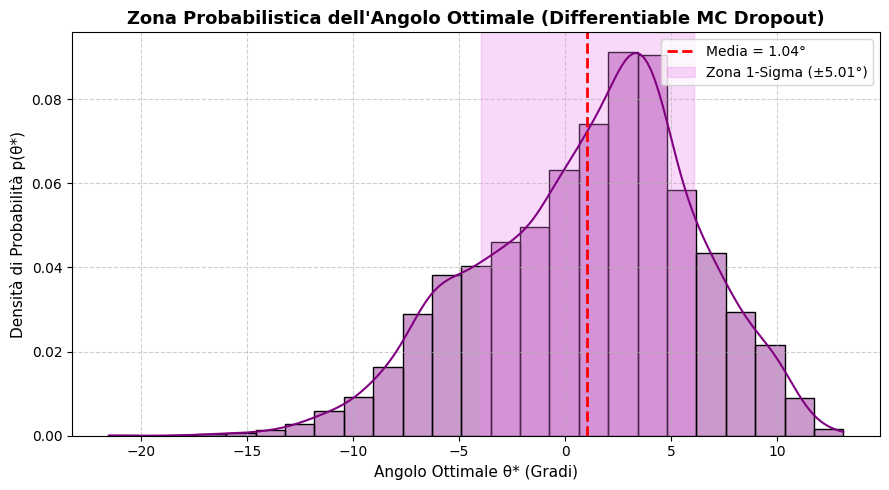

In [45]:
# ==============================================================================
# TASK 3: OTTIMIZZAZIONE ROBUSTA DIFFERENTIABILE (ZONA PROBABILISTICA VIA MC DROPOUT)
# ==============================================================================
print("\n" + "=" * 85)
print(
    "   TASK 3: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT"
    " DESCENT)"
)
print("=" * 85)

n_runs_mc = 10000  # Numero di ottimizzazioni differenziabili indipendenti
angoli_ottimi_continui = []
losses_ottime = []

# Congeliamo i pesi della rete, MA teniamo il Dropout attivo!
for param in modello.parameters():
  param.requires_grad = False

# ATTENZIONE: modello.train() garantisce che il Dropout sia attivo durante la backprop!
modello.train()

# Parametri fisici costanti
PHI_RAD = 0.0
RAGGIO_MEDIO = float(X[:, 4].mean())

mean_X = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
scale_X = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
mean_y = torch.tensor(scaler_y.mean_, dtype=torch.float32, device=device)
scale_y = torch.tensor(scaler_y.scale_, dtype=torch.float32, device=device)

print(
    f"Esecuzione di {n_runs_mc} ottimizzazioni via Gradient Descent con"
    " perturbazioni MC Dropout..."
)

for run in range(n_runs_mc):
  # Inizializziamo ogni run in prossimità della zona promettente (0° / 360°) - LOGICA ORIGINALE
  theta_param = torch.tensor(
      [np.radians(0.0)], dtype=torch.float32, device=device, requires_grad=True
  )
  optimizer_plaque = optim.Adam([theta_param], lr=0.03)

  # Breve ciclo di gradient descent per convergere sotto la maschera di dropout corrente
  for step in range(150):
    optimizer_plaque.zero_grad()

    sin_t, cos_t = torch.sin(theta_param), torch.cos(theta_param)
    sin_p = torch.tensor([np.sin(PHI_RAD)], dtype=torch.float32, device=device)
    cos_p = torch.tensor([np.cos(PHI_RAD)], dtype=torch.float32, device=device)
    r_val = torch.tensor([RAGGIO_MEDIO], dtype=torch.float32, device=device)

    x_input = (
        torch.cat([sin_t, cos_t, sin_p, cos_p, r_val]).unsqueeze(0).float()
    )
    x_input_scaled = (x_input - mean_X) / scale_X

    # Forward pass con Dropout attivo
    pred_scaled = modello(x_input_scaled)
    pred_log = (pred_scaled * scale_y) + mean_y
    pred_reale = torch.expm1(pred_log)

    loss, _ = calcola_loss_clinica(pred_reale)
    loss.backward()
    optimizer_plaque.step()

  # Salviamo l'angolo finale in gradi [0, 360)
  ang_deg = (np.degrees(theta_param.item()) % 360 + 360) % 360

  # Se l'angolo è vicinissimo a 360 (es. 359.8°), lo mappiamo a valori attorno allo 0 per continuità
  if ang_deg > 180:
    ang_deg = ang_deg - 360.0

  angoli_ottimi_continui.append(ang_deg)
  losses_ottime.append(loss.item())

  if (run + 1) % 50 == 0:
    print(f"  └ Run [{run+1:3d}/{n_runs_mc}] completata...")

# Convertiamo in numpy array
angoli_ottimi_continui = np.array(angoli_ottimi_continui)

# --- ANALISI STATISTICA CONTINUA (LOGICA ORIGINALE) ---
media_angolo = np.mean(angoli_ottimi_continui)
std_angolo = np.std(angoli_ottimi_continui)

# Convertiamo la media riportandola nell'intervallo [0, 360) solo per la stampa di testo
media_angolo_deg = (media_angolo + 360) % 360

print("\n" + "*" * 85)
print(" RISULTATI DELL'OTTIMIZZAZIONE PROBABILISTICA CONTINUA")
print("*" * 85)
print(f" Angolo Ottimale Medio (Mean θ*) : {media_angolo_deg:.2f}°")
print(f" Incertezza/Deviazione Standard (σ_θ): ±{std_angolo:.2f}°")
print(
    " Zona d'Incertezza Clinica (95% CI):"
    f" [{media_angolo_deg - 1.96*std_angolo:.2f}°,"
    f" {media_angolo_deg + 1.96*std_angolo:.2f}°]"
)
print("*" * 85)

# ==============================================================================
# GRAFICO: STIMA DELLA DENSITÀ DI PROBABILITÀ (RIGOROSAMENTE IDENTICO AL TUO)
# ==============================================================================
plt.figure(figsize=(9, 5))

# Istogramma + Curva di Densità Continua (KDE)
sns.histplot(
    angoli_ottimi_continui,
    kde=True,
    color='purple',
    stat='density',
    bins=25,
    alpha=0.4,
)

# Linea della media
plt.axvline(
    media_angolo,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media = {media_angolo_deg:.2f}°',
)

# Area della Deviazione Standard (Zona 1-Sigma)
plt.axvspan(
    media_angolo - std_angolo,
    media_angolo + std_angolo,
    color='violet',
    alpha=0.3,
    label=f'Zona 1-Sigma (±{std_angolo:.2f}°)',
)

plt.title(
    "Zona Probabilistica dell'Angolo Ottimale (Differentiable MC Dropout)",
    fontsize=13,
    fontweight='bold',
)
plt.xlabel("Angolo Ottimale θ* (Gradi)", fontsize=11)
plt.ylabel("Densità di Probabilità p(θ*)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig("probabilistic_continuous_optimal_zone.png", dpi=300)
plt.show()